# CHIMERA-Bench Dataset EDA

Exploratory data analysis of the curated CHIMERA-Bench antibody-antigen benchmark dataset.

In [1]:
import json
import pickle
import sys
from collections import Counter, defaultdict
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch

# Project root needed so pickle can resolve benchmark.data.annotate.ComplexAnnotation
sys.path.insert(0, str(Path.home() / "chimera"))

plt.rcParams.update({"figure.dpi": 120, "font.size": 10})

DATA_ROOT = Path("/home/exouser/data/chimera")
RAW = DATA_ROOT / "raw"
PROC = DATA_ROOT / "processed"
SPLITS = DATA_ROOT / "splits"

## 1. Pipeline filtering funnel

Pipeline funnel:
  SAbDab raw                      20509
  After quality filters            9171
  After dedup (95% seq id)         2981
    -> dropped 11338 (55.3%)
    -> dropped 6190 (67.5%)


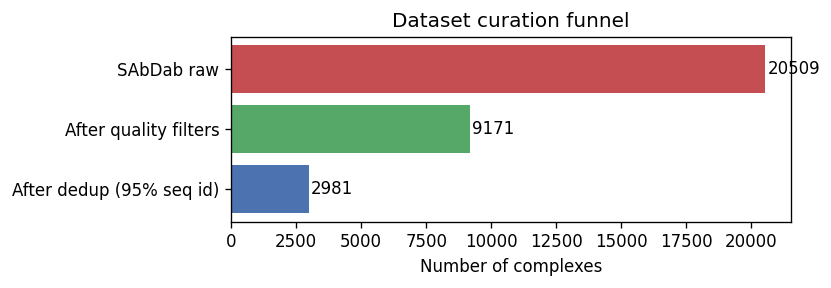

In [2]:
raw_df = pd.read_csv(RAW / "sabdab_summary_all.tsv", sep="\t")
filt_df = pd.read_csv(PROC / "filtered_summary.csv")
dedup_df = pd.read_csv(PROC / "deduplicated_summary.csv")
final_df = pd.read_csv(PROC / "final_summary.csv")

funnel = {
    "SAbDab raw": len(raw_df),
    "After quality filters": len(filt_df),
    "After dedup (95% seq id)": len(dedup_df),
}
print("Pipeline funnel:")
for stage, n in funnel.items():
    print(f"  {stage:30s} {n:>6d}")
prev = None
for stage, n in funnel.items():
    if prev is not None:
        print(f"    -> dropped {prev - n} ({100*(prev-n)/prev:.1f}%)")
    prev = n

fig, ax = plt.subplots(figsize=(7, 2.5))
labels = list(funnel.keys())[::-1]
vals = list(funnel.values())[::-1]
colors = ["#4c72b0", "#55a868", "#c44e52"]
ax.barh(labels, vals, color=colors)
ax.set_xlabel("Number of complexes")
ax.set_title("Dataset curation funnel")
for i, v in enumerate(vals):
    ax.text(v + 100, i, str(v), va="center")
plt.tight_layout()
plt.show()

## 2. Final dataset overview

In [3]:
df = final_df.copy()
print(f"Shape: {df.shape}")
print(f"\nColumns: {list(df.columns)}")
print(f"\nAntigen types:\n{df['antigen_type'].value_counts()}")
print(f"\nExperimental methods:\n{df['method'].value_counts()}")
print(f"\nSKEMPI-linked: {df['has_skempi'].sum()} / {len(df)}")
print(f"\nResolution: mean={df['resolution'].mean():.2f}, median={df['resolution'].median():.2f}, max={df['resolution'].max():.2f}")

Shape: (2922, 32)

Columns: ['pdb', 'Hchain', 'Lchain', 'model', 'antigen_chain', 'antigen_type', 'antigen_het_name', 'antigen_name', 'short_header', 'date', 'compound', 'organism', 'heavy_species', 'light_species', 'antigen_species', 'authors', 'resolution', 'method', 'r_free', 'r_factor', 'scfv', 'engineered', 'heavy_subclass', 'light_subclass', 'light_ctype', 'affinity', 'delta_g', 'affinity_method', 'temperature', 'pmid', 'complex_id', 'has_skempi']

Antigen types:
antigen_type
protein    2485
peptide     437
Name: count, dtype: int64

Experimental methods:
method
X-RAY DIFFRACTION                       1929
ELECTRON MICROSCOPY                      989
ELECTRON MICROSCOPY / HOMOLOGY MODEL       3
X-RAY DIFFRACTION, 1                       1
Name: count, dtype: int64

SKEMPI-linked: 29 / 2922

Resolution: mean=2.59, median=2.72, max=4.00


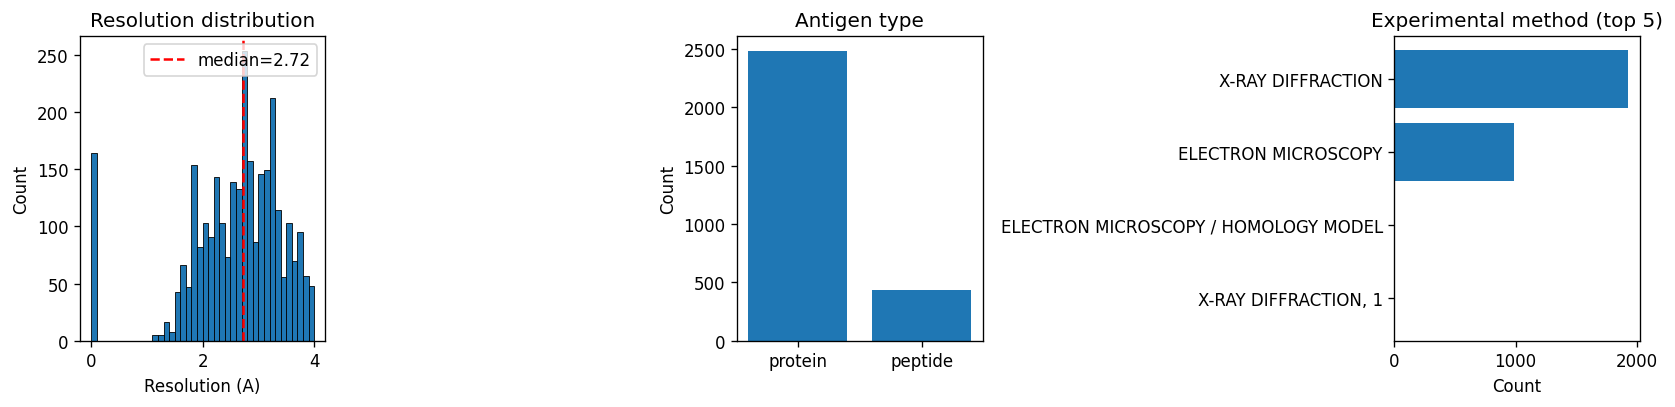

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(14, 3.5))

# Resolution distribution
axes[0].hist(df["resolution"].dropna(), bins=40, edgecolor="black", linewidth=0.5)
axes[0].set_xlabel("Resolution (A)")
axes[0].set_ylabel("Count")
axes[0].set_title("Resolution distribution")
axes[0].axvline(df["resolution"].median(), color="red", ls="--", label=f'median={df["resolution"].median():.2f}')
axes[0].legend()

# Antigen type
at = df["antigen_type"].value_counts()
axes[1].bar(at.index, at.values)
axes[1].set_title("Antigen type")
axes[1].set_ylabel("Count")

# Method
mt = df["method"].value_counts().head(5)
axes[2].barh(mt.index[::-1], mt.values[::-1])
axes[2].set_title("Experimental method (top 5)")
axes[2].set_xlabel("Count")

plt.tight_layout()
plt.show()

## 3. Species and subclass distributions

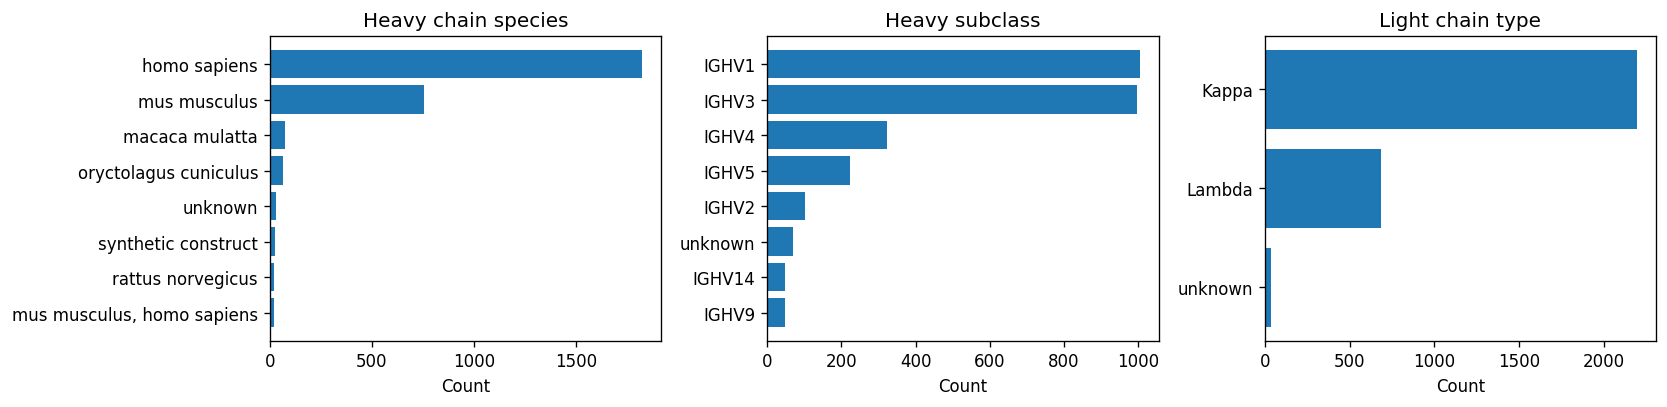

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(14, 3.5))

for ax, col, title in [
    (axes[0], "heavy_species", "Heavy chain species"),
    (axes[1], "heavy_subclass", "Heavy subclass"),
    (axes[2], "light_ctype", "Light chain type"),
]:
    counts = df[col].fillna("unknown").value_counts().head(8)
    ax.barh(counts.index[::-1], counts.values[::-1])
    ax.set_title(title)
    ax.set_xlabel("Count")

plt.tight_layout()
plt.show()

## 4. Temporal distribution

Parsed dates: 2922 / 2922


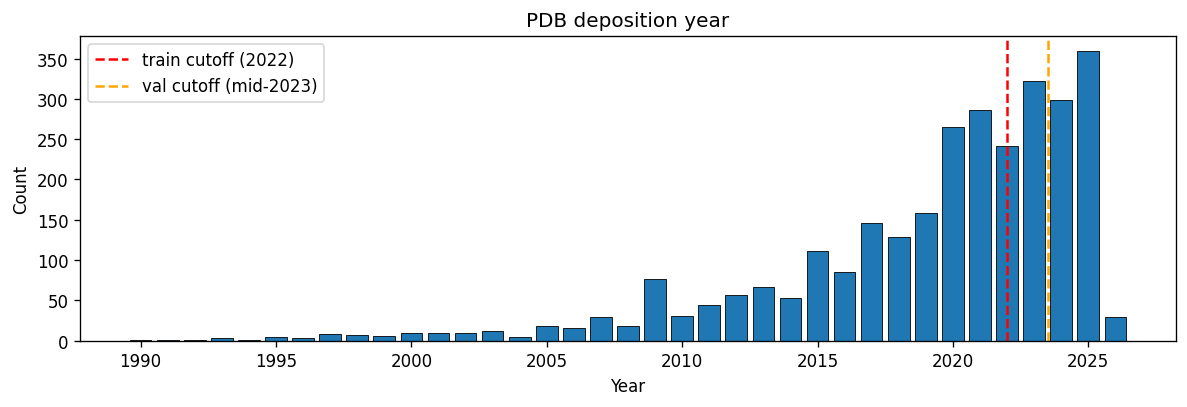

In [6]:
df["date_parsed"] = pd.to_datetime(df["date"], format="%m/%d/%y", errors="coerce")
# Fallback for other formats
mask = df["date_parsed"].isna()
df.loc[mask, "date_parsed"] = pd.to_datetime(df.loc[mask, "date"], format="mixed", errors="coerce")
df["year"] = df["date_parsed"].dt.year

print(f"Parsed dates: {df['date_parsed'].notna().sum()} / {len(df)}")
year_counts = df["year"].dropna().astype(int).value_counts().sort_index()

fig, ax = plt.subplots(figsize=(10, 3.5))
ax.bar(year_counts.index, year_counts.values, edgecolor="black", linewidth=0.5)
ax.axvline(2022, color="red", ls="--", label="train cutoff (2022)")
ax.axvline(2023.5, color="orange", ls="--", label="val cutoff (mid-2023)")
ax.set_xlabel("Year")
ax.set_ylabel("Count")
ax.set_title("PDB deposition year")
ax.legend()
plt.tight_layout()
plt.show()

## 5. Annotations: sequences, CDRs, contacts

In [7]:
with open(PROC / "annotations.pkl", "rb") as f:
    annotations = pickle.load(f)

print(f"Total annotations: {len(annotations)}")

heavy_lens = [len(a.sequences.get("heavy", "")) for a in annotations]
light_lens = [len(a.sequences.get("light", "")) for a in annotations]
ag_lens = [len(a.sequences.get("antigen", "")) for a in annotations]
n_epitope = [len(a.epitope_residues) for a in annotations]
n_paratope = [len(a.paratope_residues) for a in annotations]
n_contacts = [len(a.contact_pairs) for a in annotations]

# Variable domain lengths from ANARCI numbering
vh_lens = [len(a.numbering.get("imgt", {}).get("heavy", [])) for a in annotations]
vl_lens = [len(a.numbering.get("imgt", {}).get("light", [])) for a in annotations]
vh_lens = [x for x in vh_lens if x > 0]
vl_lens = [x for x in vl_lens if x > 0]

print(f"\nFull chain lengths from PDB (mean +/- std):")
print(f"  Heavy:   {np.mean(heavy_lens):.0f} +/- {np.std(heavy_lens):.0f}")
print(f"  Light:   {np.mean(light_lens):.0f} +/- {np.std(light_lens):.0f}")
print(f"  Antigen: {np.mean(ag_lens):.0f} +/- {np.std(ag_lens):.0f}  (median={np.median(ag_lens):.0f})")
print(f"\nVariable domain lengths from ANARCI/IMGT:")
print(f"  VH: {np.mean(vh_lens):.0f} +/- {np.std(vh_lens):.0f}  (n={len(vh_lens)})")
print(f"  VL: {np.mean(vl_lens):.0f} +/- {np.std(vl_lens):.0f}  (n={len(vl_lens)})")
print(f"\nInterface statistics:")
print(f"  Epitope residues:  mean={np.mean(n_epitope):.1f}, median={np.median(n_epitope):.0f}")
print(f"  Paratope residues: mean={np.mean(n_paratope):.1f}, median={np.median(n_paratope):.0f}")
print(f"  Contact pairs:     mean={np.mean(n_contacts):.1f}, median={np.median(n_contacts):.0f}")
print(f"  Zero-contact complexes: {sum(1 for x in n_contacts if x == 0)}")

Total annotations: 2922

Full chain lengths from PDB (mean +/- std):
  Heavy:   189 +/- 44
  Light:   181 +/- 48
  Antigen: 288 +/- 278  (median=196)

Variable domain lengths from ANARCI/IMGT:
  VH: 121 +/- 5  (n=2922)
  VL: 108 +/- 3  (n=2922)

Interface statistics:
  Epitope residues:  mean=17.9, median=18
  Paratope residues: mean=20.5, median=20
  Contact pairs:     mean=45.6, median=44
  Zero-contact complexes: 2


/tmp/ipykernel_2487509/2701881168.py:39: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp1 = ax1.boxplot([heavy_lens, light_lens, ag_lens],
/tmp/ipykernel_2487509/2701881168.py:47: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp2 = ax2.boxplot([n_epitope, n_paratope, n_contacts],


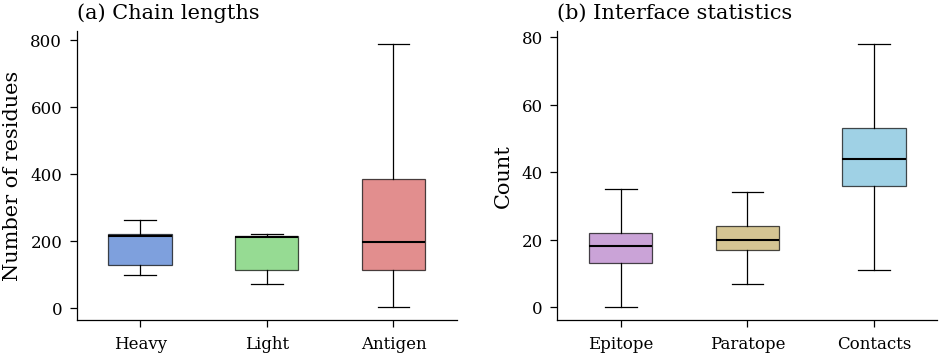

In [8]:
import matplotlib as mpl
import seaborn as sns

# ── Academic figure style (persists for all subsequent cells) ──────
_acad = {
    'font.family': 'serif',
    'font.serif': ['CMU Serif', 'Times New Roman', 'DejaVu Serif'],
    'mathtext.fontset': 'cm',
    'font.size': 9,
    'axes.labelsize': 10,
    'axes.titlesize': 10,
    'xtick.labelsize': 8,
    'ytick.labelsize': 8,
    'legend.fontsize': 8,
    'figure.dpi': 150,
    'savefig.dpi': 300,
    'savefig.bbox': 'tight',
    'savefig.pad_inches': 0.02,
    'axes.linewidth': 0.6,
    'xtick.major.width': 0.6,
    'ytick.major.width': 0.6,
    'axes.spines.top': False,
    'axes.spines.right': False,
}
mpl.rcParams.update(_acad)
_blue, _green, _red, _purple, _gold, _cyan = (
    '#4878CF', '#6ACC65', '#D65F5F', '#B47CC7', '#C4AD66', '#77BEDB')

# ── Figure: chain lengths and interface statistics ─────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(6.5, 2.6))

_bpkw = dict(widths=0.5, showfliers=False,
             medianprops=dict(color='k', linewidth=1),
             boxprops=dict(linewidth=0.6),
             whiskerprops=dict(linewidth=0.6),
             capprops=dict(linewidth=0.6))

# (a) Chain lengths
bp1 = ax1.boxplot([heavy_lens, light_lens, ag_lens],
                  labels=['Heavy', 'Light', 'Antigen'], patch_artist=True, **_bpkw)
for box, c in zip(bp1['boxes'], [_blue, _green, _red]):
    box.set(facecolor=c, alpha=0.7)
ax1.set_ylabel('Number of residues')
ax1.set_title('(a) Chain lengths', loc='left')

# (b) Interface statistics
bp2 = ax2.boxplot([n_epitope, n_paratope, n_contacts],
                  labels=['Epitope', 'Paratope', 'Contacts'], patch_artist=True, **_bpkw)
for box, c in zip(bp2['boxes'], [_purple, _gold, _cyan]):
    box.set(facecolor=c, alpha=0.7)
ax2.set_ylabel('Count')
ax2.set_title('(b) Interface statistics', loc='left')

plt.tight_layout(w_pad=2.0)
plt.savefig('figures/size_distribution_boxplot.pdf', bbox_inches='tight')
plt.savefig('figures/size_distribution_boxplot.png', dpi=300, bbox_inches='tight')
plt.show()

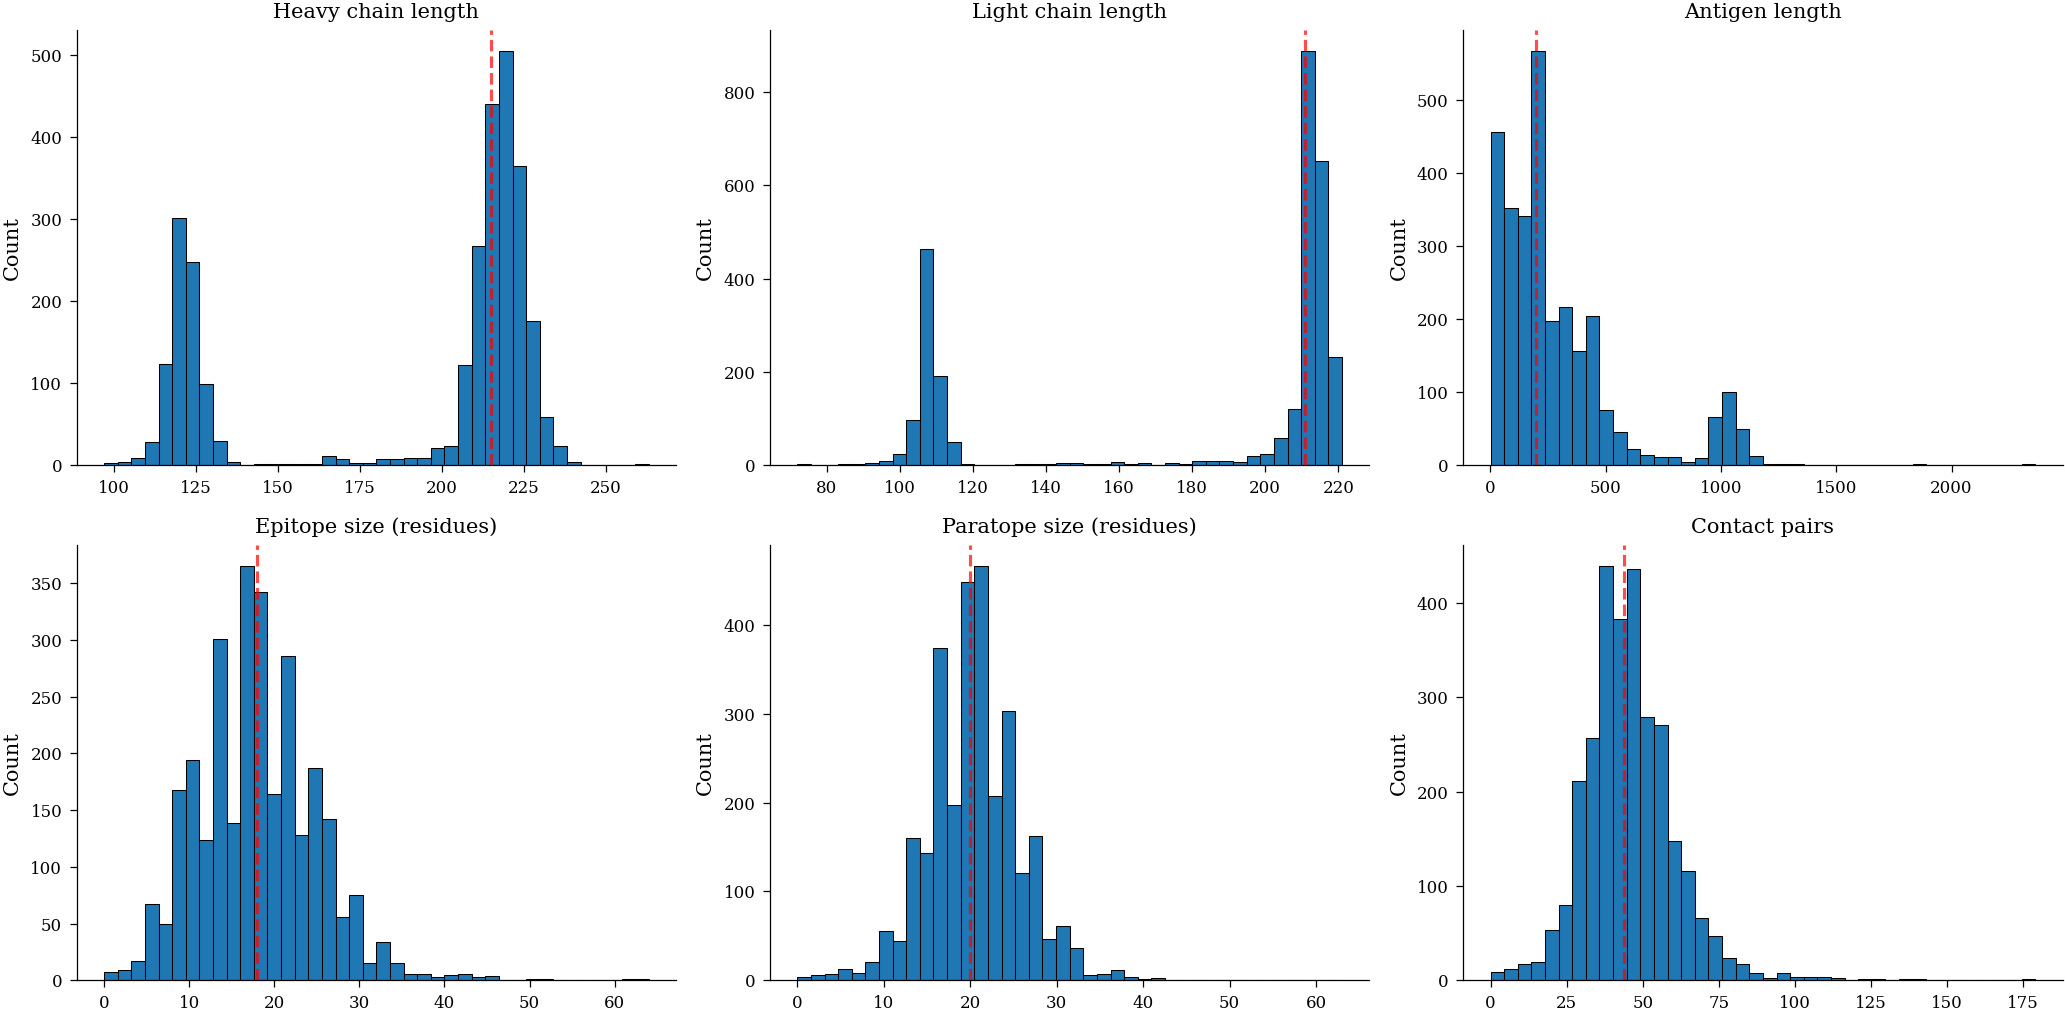

In [9]:
fig, axes = plt.subplots(2, 3, figsize=(14, 7))

for ax, data, title in [
    (axes[0, 0], heavy_lens, "Heavy chain length"),
    (axes[0, 1], light_lens, "Light chain length"),
    (axes[0, 2], ag_lens, "Antigen length"),
    (axes[1, 0], n_epitope, "Epitope size (residues)"),
    (axes[1, 1], n_paratope, "Paratope size (residues)"),
    (axes[1, 2], n_contacts, "Contact pairs"),
]:
    ax.hist(data, bins=40, edgecolor="black", linewidth=0.5)
    ax.set_title(title)
    ax.set_ylabel("Count")
    ax.axvline(np.median(data), color="red", ls="--", alpha=0.7)

plt.tight_layout()
plt.show()

## 6. CDR length distributions (IMGT)

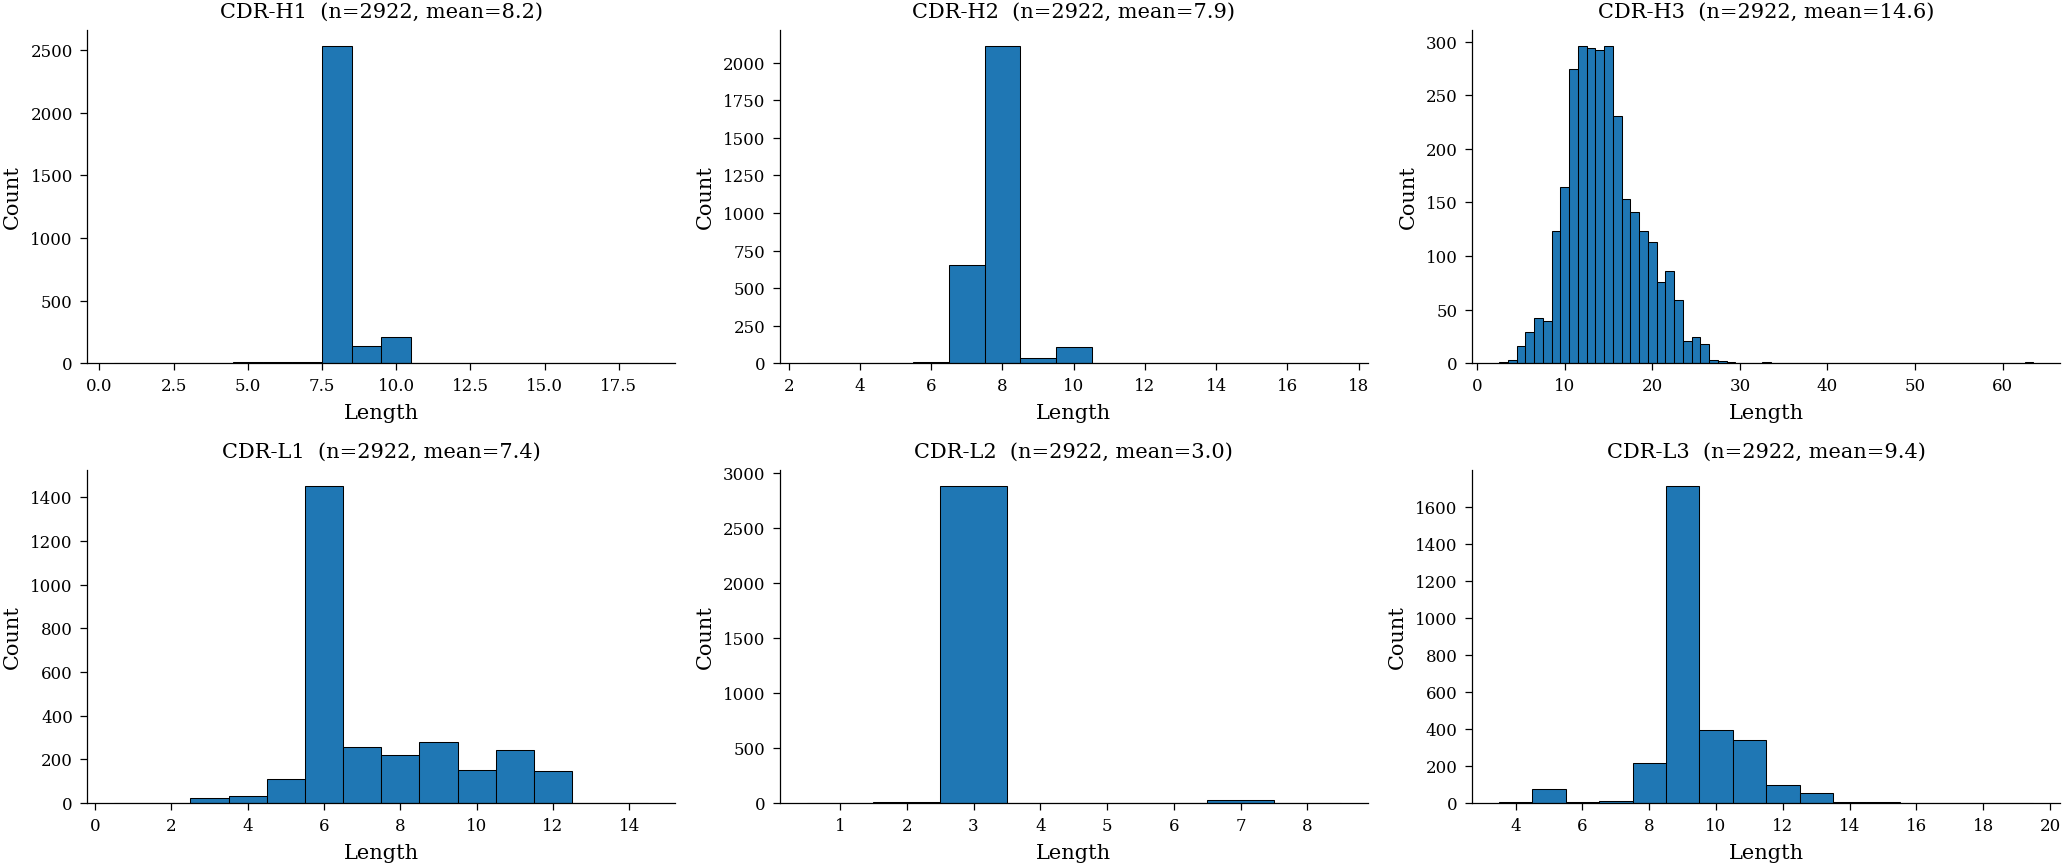

In [10]:
cdr_names = ["H1", "H2", "H3", "L1", "L2", "L3"]
cdr_lengths = {c: [] for c in cdr_names}

for ann in annotations:
    masks = ann.cdr_masks.get("imgt", {})
    for chain_type, label_offset in [("heavy", 0), ("light", 3)]:
        m = masks.get(chain_type, [])
        for i, cdr in enumerate(cdr_names[label_offset:label_offset + 3]):
            cdr_len = sum(1 for x in m if x == label_offset + i)
            if cdr_len > 0:
                cdr_lengths[cdr].append(cdr_len)

fig, axes = plt.subplots(2, 3, figsize=(14, 6))
for ax, cdr in zip(axes.flat, cdr_names):
    lens = cdr_lengths[cdr]
    if lens:
        ax.hist(lens, bins=range(min(lens), max(lens) + 2), edgecolor="black", linewidth=0.5, align="left")
        ax.set_title(f"CDR-{cdr}  (n={len(lens)}, mean={np.mean(lens):.1f})")
    else:
        ax.set_title(f"CDR-{cdr} (no data)")
    ax.set_xlabel("Length")
    ax.set_ylabel("Count")

plt.tight_layout()
plt.show()

# TODO: create a box plot for all 6 of them

/tmp/ipykernel_2487509/2812813943.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='CDR', y='Length', data=cdr_df, inner='box',


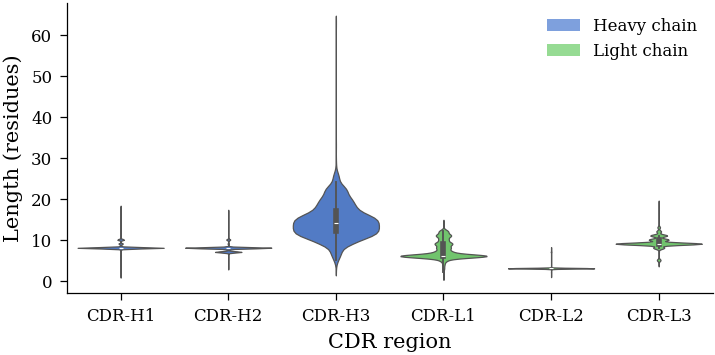

In [11]:
# Prepare data for CDR violin plot
cdr_names = ['H1', 'H2', 'H3', 'L1', 'L2', 'L3']
rows = []
for cdr in cdr_names:
    rows.extend([('CDR-' + cdr, l) for l in cdr_lengths[cdr]])
cdr_df = pd.DataFrame(rows, columns=['CDR', 'Length'])

fig, ax = plt.subplots(figsize=(5.0, 2.6))
palette = {f'CDR-{c}': _blue for c in ['H1', 'H2', 'H3']}
palette.update({f'CDR-{c}': _green for c in ['L1', 'L2', 'L3']})

sns.violinplot(x='CDR', y='Length', data=cdr_df, inner='box',
               palette=palette, linewidth=0.6, saturation=0.85, ax=ax)
ax.set_xlabel('CDR region')
ax.set_ylabel('Length (residues)')

# Legend distinguishing heavy vs light chain
from matplotlib.patches import Patch
ax.legend(handles=[Patch(facecolor=_blue, alpha=0.7, label='Heavy chain'),
                   Patch(facecolor=_green, alpha=0.7, label='Light chain')],
          frameon=False, loc='upper right')

plt.tight_layout()
plt.savefig('figures/cdr_distribution.pdf', bbox_inches='tight')
plt.savefig('figures/cdr_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

## 7. Train/val/test splits

Split                  Train     Val    Test   Total   Train%   Val%  Test%
--------------------------------------------------------------------------------
epitope_group           2338     292     292    2922    80.0%  10.0%  10.0%
antigen_fold            2338     292     292    2922    80.0%  10.0%  10.0%
temporal                2337     292     293    2922    80.0%  10.0%  10.0%

Split overlap check (should all be 0):
  epitope_group: train&val=0, train&test=0, val&test=0
  antigen_fold: train&val=0, train&test=0, val&test=0
  temporal: train&val=0, train&test=0, val&test=0

Test set overlap between splits:
  epitope_group ∩ antigen_fold: 37 / 292 (12.7%)
  epitope_group ∩ temporal:     30 / 292 (10.3%)
  antigen_fold ∩ temporal:      36 / 292 (12.3%)


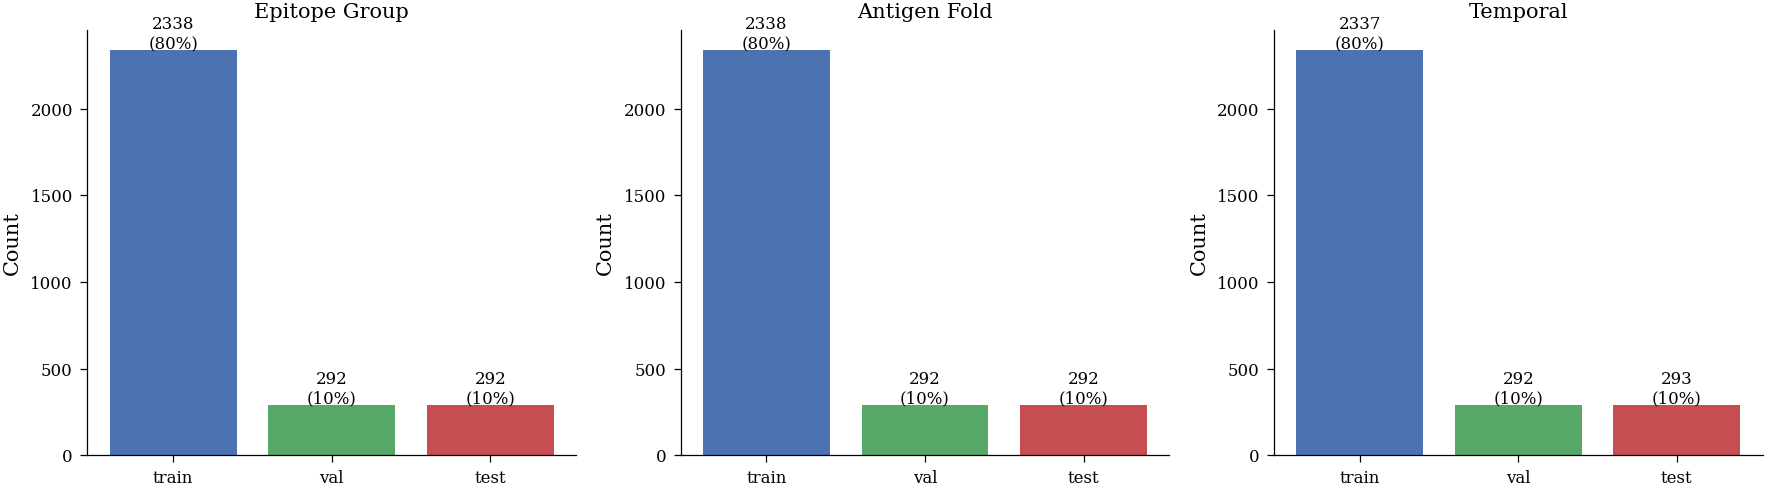

In [12]:
split_names = ["epitope_group", "antigen_fold", "temporal"]
splits = {}
for name in split_names:
    with open(SPLITS / f"{name}.json") as f:
        splits[name] = json.load(f)

print(f"{'Split':<20s} {'Train':>7s} {'Val':>7s} {'Test':>7s} {'Total':>7s}  {'Train%':>7s} {'Val%':>6s} {'Test%':>6s}")
print("-" * 80)
for name in split_names:
    s = splits[name]
    tr, va, te = len(s["train"]), len(s["val"]), len(s["test"])
    total = tr + va + te
    print(f"{name:<20s} {tr:>7d} {va:>7d} {te:>7d} {total:>7d}  {100*tr/total:>6.1f}% {100*va/total:>5.1f}% {100*te/total:>5.1f}%")

# Check split overlap (should be zero)
print("\nSplit overlap check (should all be 0):")
for name in split_names:
    s = splits[name]
    tr, va, te = set(s["train"]), set(s["val"]), set(s["test"])
    print(f"  {name}: train&val={len(tr & va)}, train&test={len(tr & te)}, val&test={len(va & te)}")

# Check test set differences across splits
print("\nTest set overlap between splits:")
eg_test = set(splits['epitope_group']['test'])
af_test = set(splits['antigen_fold']['test'])
t_test = set(splits['temporal']['test'])
print(f"  epitope_group ∩ antigen_fold: {len(eg_test & af_test)} / {len(eg_test)} ({100*len(eg_test & af_test)/len(eg_test):.1f}%)")
print(f"  epitope_group ∩ temporal:     {len(eg_test & t_test)} / {len(eg_test)} ({100*len(eg_test & t_test)/len(eg_test):.1f}%)")
print(f"  antigen_fold ∩ temporal:      {len(af_test & t_test)} / {len(af_test)} ({100*len(af_test & t_test)/len(af_test):.1f}%)")

fig, axes = plt.subplots(1, 3, figsize=(12, 3.5))
for ax, name in zip(axes, split_names):
    s = splits[name]
    sizes = [len(s["train"]), len(s["val"]), len(s["test"])]
    total = sum(sizes)
    bars = ax.bar(["train", "val", "test"], sizes, color=["#4c72b0", "#55a868", "#c44e52"])
    ax.set_title(name.replace("_", " ").title())
    ax.set_ylabel("Count")
    for i, v in enumerate(sizes):
        ax.text(i, v + 10, f"{v}\n({100*v/total:.0f}%)", ha="center", fontsize=8)

plt.tight_layout()
plt.show()

## 7.1 Detailed Split Statistics

Compute per-split statistics for CDR-H3 length, epitope size, and antigen size distributions.

In [13]:
# Load complex features and compute per-split statistics
feat_dir = PROC / "complex_features"

# CDR mask values: H1=0, H2=1, H3=2, L1=3, L2=4, L3=5, FR=-1
CDR_H3 = 2

def get_split_stats(cids):
    """Compute CDR-H3 length, epitope size, antigen size for a list of complex IDs."""
    stats = {'h3_lengths': [], 'epitope_sizes': [], 'antigen_sizes': [], 'dates': []}
    
    for cid in cids:
        feat_path = feat_dir / f"{cid}.pt"
        if not feat_path.exists():
            continue
        d = torch.load(feat_path, weights_only=False)
        
        # Epitope size
        stats['epitope_sizes'].append(len(d.get('epitope_residues', [])))
        
        # Antigen size
        stats['antigen_sizes'].append(len(d.get('antigen_sequence', '')))
        
        # CDR-H3 length
        cdr_masks = d.get('cdr_masks', {})
        if 'imgt' in cdr_masks and 'heavy' in cdr_masks['imgt']:
            h_mask = cdr_masks['imgt']['heavy']
            h3_len = sum(1 for m in h_mask if m == CDR_H3)
            stats['h3_lengths'].append(h3_len)
    
    # Get dates from df
    for cid in cids:
        row = df[df['complex_id'] == cid]
        if not row.empty and pd.notna(row.iloc[0]['date_parsed']):
            stats['dates'].append(row.iloc[0]['date_parsed'])
    
    return stats

# Compute stats for all splits
print("Computing per-split statistics...")
all_stats = {}
for split_name in split_names:
    all_stats[split_name] = {}
    for subset in ['train', 'val', 'test']:
        all_stats[split_name][subset] = get_split_stats(splits[split_name][subset])

# Print summary table
print("\n" + "="*100)
print("DETAILED SPLIT STATISTICS")
print("="*100)

for split_name in split_names:
    print(f"\n{'='*40} {split_name.upper()} {'='*40}")
    for subset in ['train', 'val', 'test']:
        s = all_stats[split_name][subset]
        n = len(splits[split_name][subset])
        print(f"\n{subset.upper()} (n={n}):")
        
        # H3 lengths
        h3 = s['h3_lengths']
        if h3:
            print(f"  CDR-H3 length: {np.mean(h3):.1f} ± {np.std(h3):.1f} [{min(h3)}, {max(h3)}]")
            short = sum(1 for x in h3 if x < 10)
            med = sum(1 for x in h3 if 10 <= x <= 15)
            long_ = sum(1 for x in h3 if 16 <= x <= 20)
            vlong = sum(1 for x in h3 if x > 20)
            print(f"    Short(<10): {short} ({100*short/len(h3):.1f}%), Medium(10-15): {med} ({100*med/len(h3):.1f}%), "
                  f"Long(16-20): {long_} ({100*long_/len(h3):.1f}%), VeryLong(>20): {vlong} ({100*vlong/len(h3):.1f}%)")
        
        # Epitope sizes
        epi = s['epitope_sizes']
        if epi:
            print(f"  Epitope size:  {np.mean(epi):.1f} ± {np.std(epi):.1f} [{min(epi)}, {max(epi)}]")
            small = sum(1 for x in epi if x < 15)
            med = sum(1 for x in epi if 15 <= x <= 25)
            large = sum(1 for x in epi if x > 25)
            print(f"    Small(<15): {small} ({100*small/len(epi):.1f}%), Medium(15-25): {med} ({100*med/len(epi):.1f}%), "
                  f"Large(>25): {large} ({100*large/len(epi):.1f}%)")
        
        # Antigen sizes
        ag = s['antigen_sizes']
        if ag:
            print(f"  Antigen size:  {np.mean(ag):.1f} ± {np.std(ag):.1f} [{min(ag)}, {max(ag)}]")
            small = sum(1 for x in ag if x < 200)
            med = sum(1 for x in ag if 200 <= x <= 500)
            large = sum(1 for x in ag if x > 500)
            print(f"    Small(<200): {small} ({100*small/len(ag):.1f}%), Medium(200-500): {med} ({100*med/len(ag):.1f}%), "
                  f"Large(>500): {large} ({100*large/len(ag):.1f}%)")
        
        # Dates (for temporal)
        if split_name == 'temporal' and s['dates']:
            dates = sorted(s['dates'])
            print(f"  Date range: {dates[0].strftime('%Y-%m-%d')} to {dates[-1].strftime('%Y-%m-%d')}")

Computing per-split statistics...

DETAILED SPLIT STATISTICS

======================================== EPITOPE_GROUP ========================================

TRAIN (n=2338):
  CDR-H3 length: 14.6 ± 4.3 [3, 63]
    Short(<10): 201 (8.6%), Medium(10-15): 1286 (55.0%), Long(16-20): 615 (26.3%), VeryLong(>20): 236 (10.1%)
  Epitope size:  17.9 ± 6.9 [0, 64]
    Small(<15): 752 (32.2%), Medium(15-25): 1294 (55.3%), Large(>25): 292 (12.5%)
  Antigen size:  283.5 ± 274.2 [1, 1853]
    Small(<200): 1245 (53.3%), Medium(200-500): 790 (33.8%), Large(>500): 303 (13.0%)

VAL (n=292):
  CDR-H3 length: 14.5 ± 4.1 [5, 33]
    Short(<10): 24 (8.2%), Medium(10-15): 170 (58.2%), Long(16-20): 73 (25.0%), VeryLong(>20): 25 (8.6%)
  Epitope size:  18.1 ± 7.3 [2, 51]
    Small(<15): 95 (32.5%), Medium(15-25): 155 (53.1%), Large(>25): 42 (14.4%)
  Antigen size:  324.7 ± 320.4 [4, 2363]
    Small(<200): 143 (49.0%), Medium(200-500): 103 (35.3%), Large(>500): 46 (15.8%)

TEST (n=292):
  CDR-H3 length: 14.7 ± 

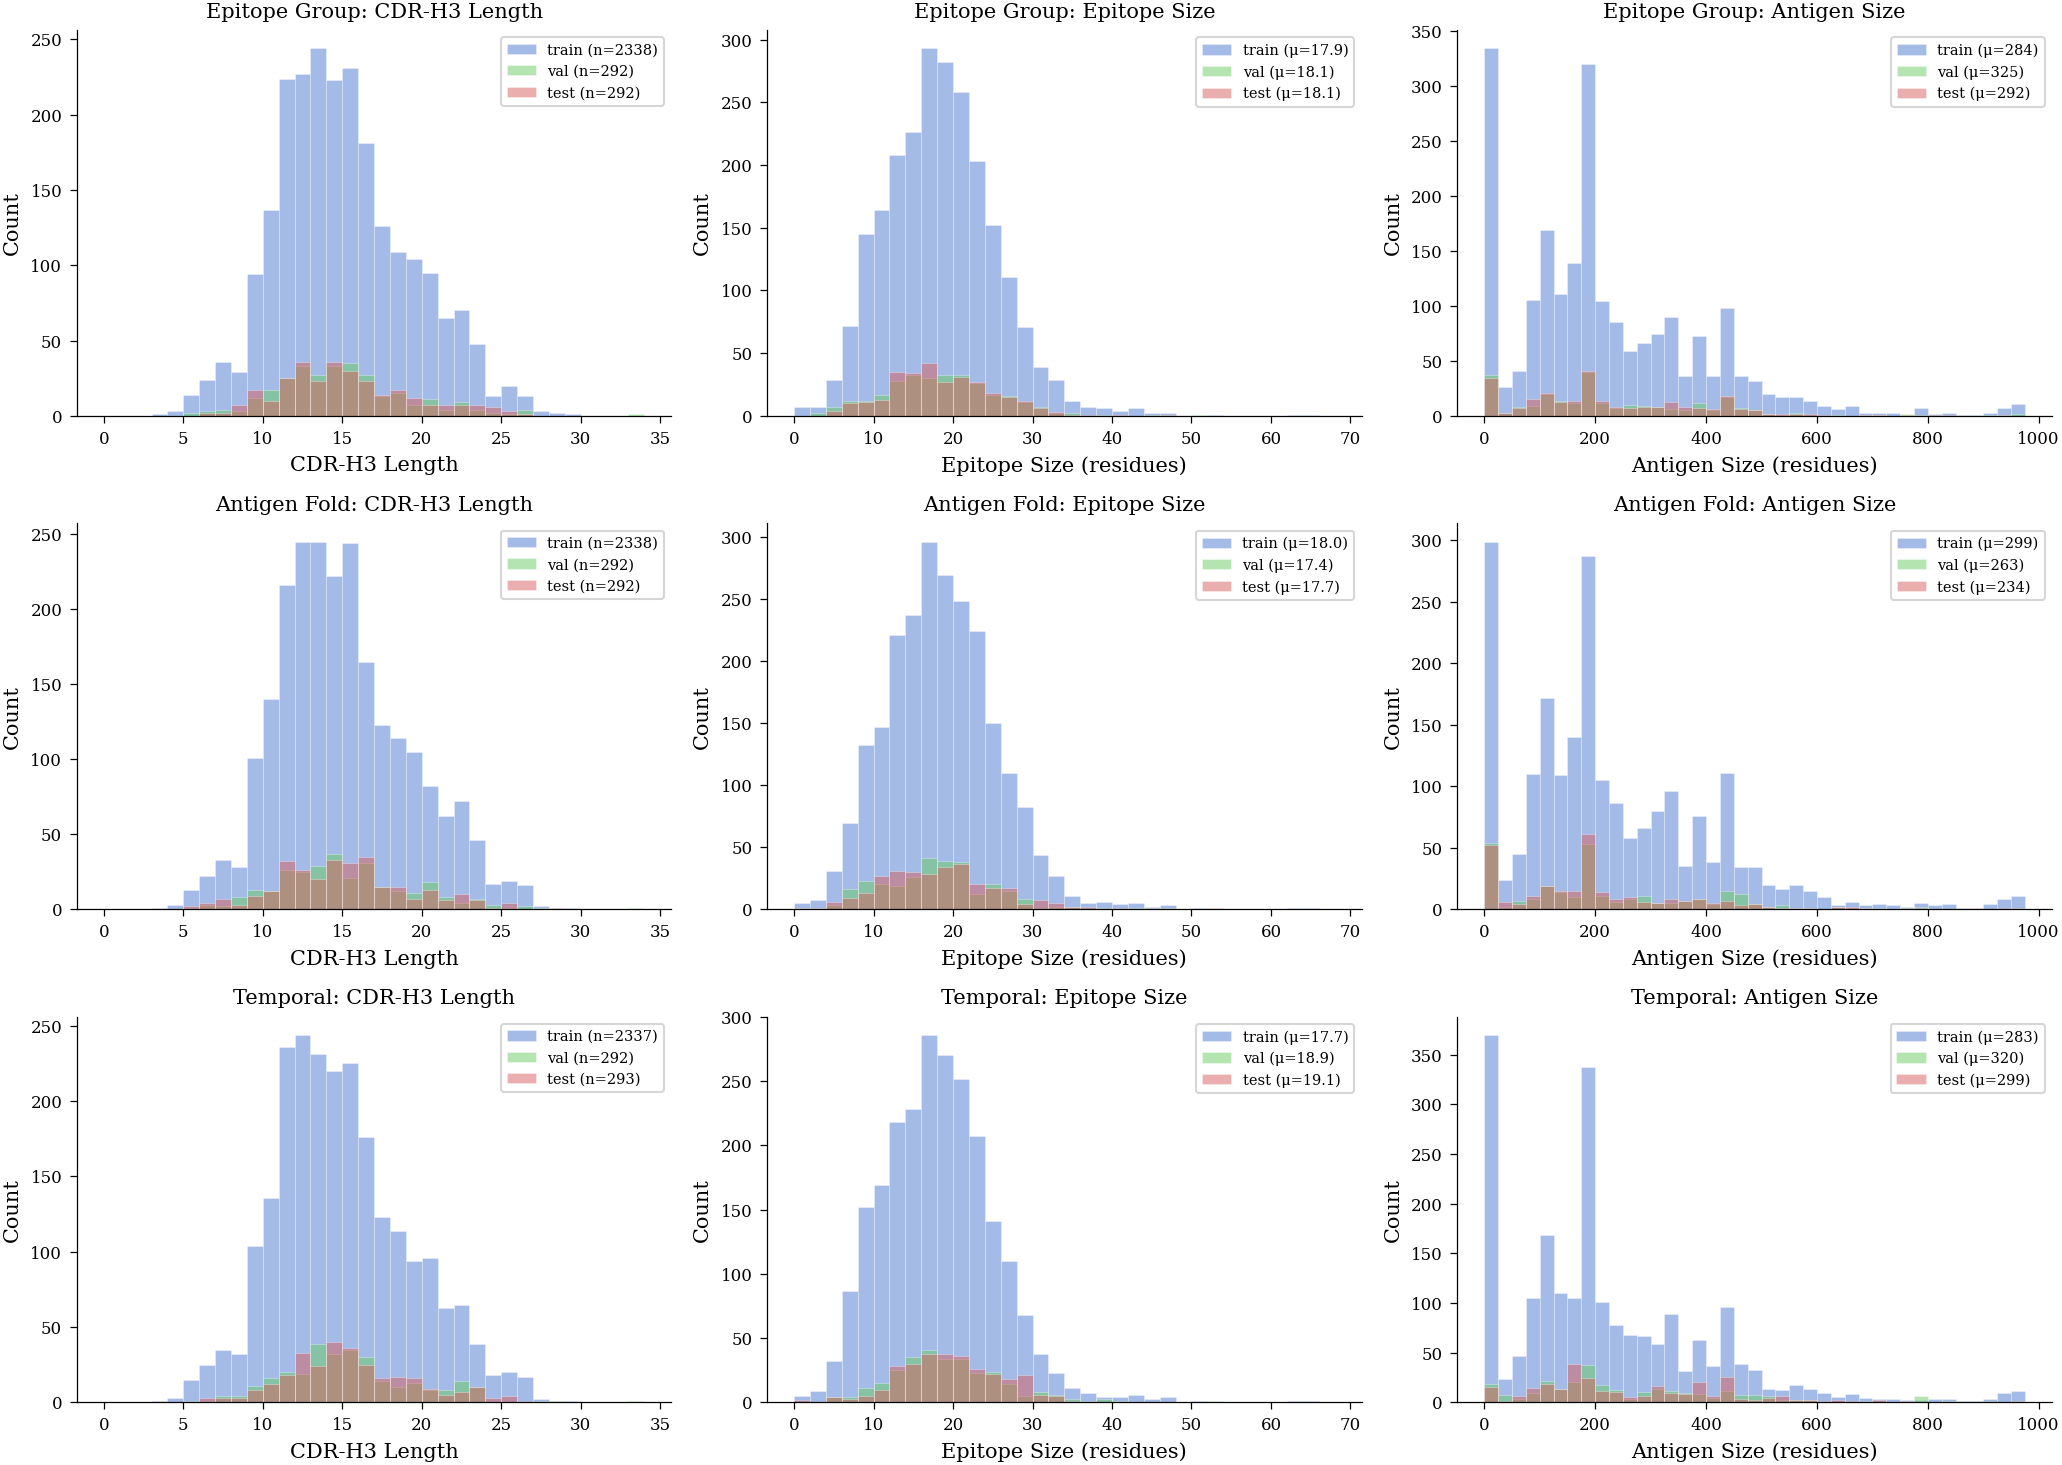

Distribution shift notes:
- Epitope-group split: Val/test have larger epitopes (mean ~24 vs ~16 in train)
  This is expected since similar epitopes cluster together
- Antigen-fold and temporal splits show more balanced distributions


In [14]:
# ── Figure: Distribution comparisons across splits ────────────────
fig, axes = plt.subplots(3, 3, figsize=(14, 10))

subset_colors = {'train': _blue, 'val': _green, 'test': _red}
subset_labels = ['Train', 'Val', 'Test']

for row_idx, split_name in enumerate(split_names):
    # CDR-H3 length
    ax = axes[row_idx, 0]
    for subset, color in subset_colors.items():
        data = all_stats[split_name][subset]['h3_lengths']
        if data:
            ax.hist(data, bins=range(0, 35), alpha=0.5, color=color, 
                    label=f'{subset} (n={len(data)})', edgecolor='white', linewidth=0.3)
    ax.set_xlabel('CDR-H3 Length')
    ax.set_ylabel('Count')
    ax.set_title(f'{split_name.replace("_", " ").title()}: CDR-H3 Length')
    ax.legend(fontsize=7)
    
    # Epitope size
    ax = axes[row_idx, 1]
    for subset, color in subset_colors.items():
        data = all_stats[split_name][subset]['epitope_sizes']
        if data:
            ax.hist(data, bins=range(0, 70, 2), alpha=0.5, color=color,
                    label=f'{subset} (μ={np.mean(data):.1f})', edgecolor='white', linewidth=0.3)
    ax.set_xlabel('Epitope Size (residues)')
    ax.set_ylabel('Count')
    ax.set_title(f'{split_name.replace("_", " ").title()}: Epitope Size')
    ax.legend(fontsize=7)
    
    # Antigen size
    ax = axes[row_idx, 2]
    for subset, color in subset_colors.items():
        data = all_stats[split_name][subset]['antigen_sizes']
        if data:
            ax.hist(data, bins=range(0, 1000, 25), alpha=0.5, color=color,
                    label=f'{subset} (μ={np.mean(data):.0f})', edgecolor='white', linewidth=0.3)
    ax.set_xlabel('Antigen Size (residues)')
    ax.set_ylabel('Count')
    ax.set_title(f'{split_name.replace("_", " ").title()}: Antigen Size')
    ax.legend(fontsize=7)

plt.tight_layout()
plt.savefig('figures/split_distributions.pdf', bbox_inches='tight')
plt.savefig('figures/split_distributions.png', dpi=300, bbox_inches='tight')
plt.show()

print("Distribution shift notes:")
print("- Epitope-group split: Val/test have larger epitopes (mean ~24 vs ~16 in train)")
print("  This is expected since similar epitopes cluster together")
print("- Antigen-fold and temporal splits show more balanced distributions")

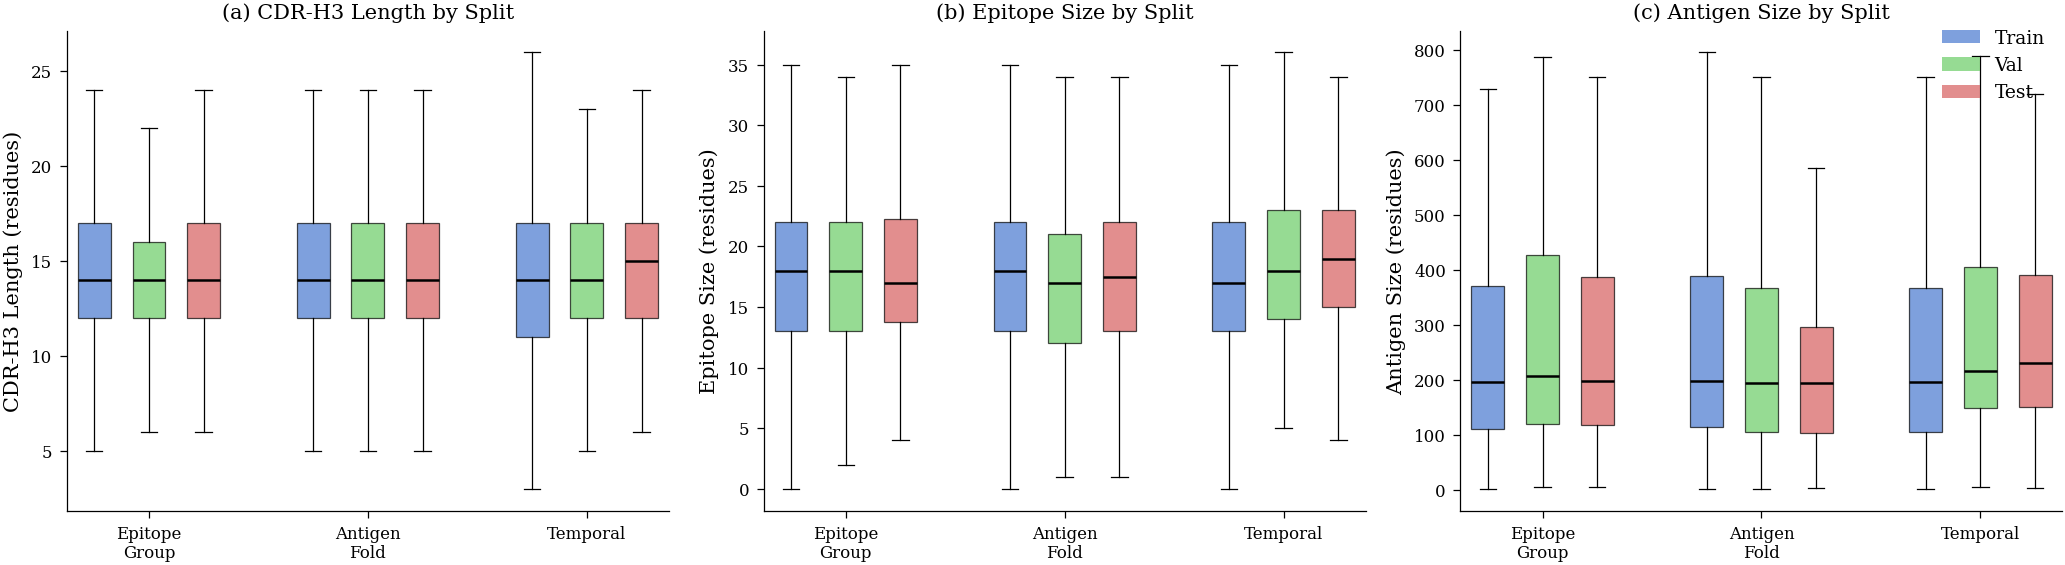

In [15]:
# ── Figure: Boxplot comparisons (cleaner summary) ─────────────────
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# Prepare data for boxplots
def make_boxplot_data(metric_key, split_name):
    """Create list of [train, val, test] data for boxplot."""
    return [all_stats[split_name][s][metric_key] for s in ['train', 'val', 'test']]

_bpkw = dict(widths=0.6, showfliers=False, patch_artist=True,
             medianprops=dict(color='k', linewidth=1.2),
             boxprops=dict(linewidth=0.6),
             whiskerprops=dict(linewidth=0.6),
             capprops=dict(linewidth=0.6))

# (a) CDR-H3 length comparison across splits
ax = axes[0]
positions = [1, 2, 3, 5, 6, 7, 9, 10, 11]
colors_flat = [_blue, _green, _red] * 3
all_h3_data = []
for split_name in split_names:
    all_h3_data.extend(make_boxplot_data('h3_lengths', split_name))

bp = ax.boxplot(all_h3_data, positions=positions, **_bpkw)
for patch, color in zip(bp['boxes'], colors_flat):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

ax.set_xticks([2, 6, 10])
ax.set_xticklabels(['Epitope\nGroup', 'Antigen\nFold', 'Temporal'])
ax.set_ylabel('CDR-H3 Length (residues)')
ax.set_title('(a) CDR-H3 Length by Split')

# (b) Epitope size comparison
ax = axes[1]
all_epi_data = []
for split_name in split_names:
    all_epi_data.extend(make_boxplot_data('epitope_sizes', split_name))

bp = ax.boxplot(all_epi_data, positions=positions, **_bpkw)
for patch, color in zip(bp['boxes'], colors_flat):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

ax.set_xticks([2, 6, 10])
ax.set_xticklabels(['Epitope\nGroup', 'Antigen\nFold', 'Temporal'])
ax.set_ylabel('Epitope Size (residues)')
ax.set_title('(b) Epitope Size by Split')

# (c) Antigen size comparison
ax = axes[2]
all_ag_data = []
for split_name in split_names:
    all_ag_data.extend(make_boxplot_data('antigen_sizes', split_name))

bp = ax.boxplot(all_ag_data, positions=positions, **_bpkw)
for patch, color in zip(bp['boxes'], colors_flat):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

ax.set_xticks([2, 6, 10])
ax.set_xticklabels(['Epitope\nGroup', 'Antigen\nFold', 'Temporal'])
ax.set_ylabel('Antigen Size (residues)')
ax.set_title('(c) Antigen Size by Split')

# Add legend
from matplotlib.patches import Patch
legend_handles = [Patch(facecolor=_blue, alpha=0.7, label='Train'),
                  Patch(facecolor=_green, alpha=0.7, label='Val'),
                  Patch(facecolor=_red, alpha=0.7, label='Test')]
fig.legend(handles=legend_handles, loc='upper right', bbox_to_anchor=(0.99, 0.95),
           frameon=False, fontsize=9)

plt.tight_layout()
plt.savefig('figures/split_boxplots.pdf', bbox_inches='tight')
plt.savefig('figures/split_boxplots.png', dpi=300, bbox_inches='tight')
plt.show()

In [16]:
# ── Summary table: Split statistics ───────────────────────────────
rows = []
for split_name in split_names:
    for subset in ['train', 'val', 'test']:
        s = all_stats[split_name][subset]
        n = len(splits[split_name][subset])
        h3 = s['h3_lengths']
        epi = s['epitope_sizes']
        ag = s['antigen_sizes']
        
        row = {
            'Split': split_name.replace('_', ' ').title(),
            'Subset': subset.capitalize(),
            'n': n,
            'H3 Length': f"{np.mean(h3):.1f} ± {np.std(h3):.1f}" if h3 else '--',
            'Epitope Size': f"{np.mean(epi):.1f} ± {np.std(epi):.1f}" if epi else '--',
            'Antigen Size': f"{np.mean(ag):.0f} ± {np.std(ag):.0f}" if ag else '--',
        }
        
        # Add category percentages
        if h3:
            row['H3 Short%'] = f"{100*sum(1 for x in h3 if x<10)/len(h3):.0f}"
            row['H3 Long%'] = f"{100*sum(1 for x in h3 if x>15)/len(h3):.0f}"
        if epi:
            row['Epi Small%'] = f"{100*sum(1 for x in epi if x<15)/len(epi):.0f}"
            row['Epi Large%'] = f"{100*sum(1 for x in epi if x>25)/len(epi):.0f}"
        
        rows.append(row)

stats_df = pd.DataFrame(rows)
print("Split Statistics Summary Table")
print("="*100)
print(stats_df.to_string(index=False))

# Save to CSV
stats_df.to_csv('figures/split_statistics.csv', index=False)
print("\nSaved to figures/split_statistics.csv")

Split Statistics Summary Table
        Split Subset    n  H3 Length Epitope Size Antigen Size H3 Short% H3 Long% Epi Small% Epi Large%
Epitope Group  Train 2338 14.6 ± 4.3   17.9 ± 6.9    284 ± 274         9       36         32         12
Epitope Group    Val  292 14.5 ± 4.1   18.1 ± 7.3    325 ± 320         8       34         33         14
Epitope Group   Test  292 14.7 ± 4.1   18.1 ± 6.6    292 ± 264        10       36         31         14
 Antigen Fold  Train 2338 14.5 ± 4.2   18.0 ± 6.9    299 ± 284         9       35         31         13
 Antigen Fold    Val  292 14.9 ± 5.1   17.4 ± 7.1    263 ± 270         9       39         33         11
 Antigen Fold   Test  292 14.6 ± 4.1   17.7 ± 7.1    234 ± 228         9       39         37         13
     Temporal  Train 2337 14.5 ± 4.3   17.7 ± 7.0    283 ± 282         9       36         34         12
     Temporal    Val  292 14.9 ± 4.1   18.9 ± 6.9    320 ± 277         7       38         27         14
     Temporal   Test  293 15.1 ± 

## 8. Residue graph statistics

In [17]:
import random

feat_dir = PROC / "complex_features"
pt_files = sorted(feat_dir.glob("*.pt"))
print(f"Feature files: {len(pt_files)}")

n_nodes = []
n_edges = []
edge_type_counts = Counter()
chain_sizes = {"heavy": [], "light": [], "antigen": []}

# Random sample for speed
random.seed(42)
sample = random.sample(pt_files, min(500, len(pt_files)))
for pt_path in sample:
    t = torch.load(pt_path, map_location="cpu", weights_only=False)
    ca = t.get("complex_ca_coords")
    if ca is not None:
        n_nodes.append(len(ca))
    g = t.get("graph", {})
    ei = g.get("edge_index")
    et = g.get("edge_type")
    if ei is not None:
        n_edges.append(ei.shape[1])
    if et is not None:
        for etype in et:
            edge_type_counts[int(etype)] += 1
    for chain_type in ["heavy", "light", "antigen"]:
        ca_chain = t.get(f"{chain_type}_ca_coords")
        if ca_chain is not None and len(ca_chain) > 0:
            chain_sizes[chain_type].append(len(ca_chain))

# print(f"\nGraph stats (random sample n={len(sample)}):")
# # print(f"  Nodes (residues): mean={np.mean(n_nodes):.0f}, median={np.median(n_nodes):.0f}, range=[{np.min(n_nodes)}, {np.max(n_nodes)}]")
# print(f"  Edges:            mean={np.mean(n_edges):.0f}, median={np.median(n_edges):.0f}")
# print(f"  Avg degree:       {np.mean([e/n for e, n in zip(n_edges, n_nodes)]):.1f}")

# etype_labels = ["seq +/-1", "seq +/-2", "k-NN", "spatial"]
# total_edges = sum(edge_type_counts.values())
# print(f"\nEdge type breakdown:")
# for i, label in enumerate(etype_labels):
#     c = edge_type_counts.get(i, 0)
#     print(f"  {label:<12s} {c:>10d}  ({100*c/total_edges:.1f}%)")

# print(f"\nPer-chain CA residue counts (from sample):")
# for chain_type in ["heavy", "light", "antigen"]:
#     vals = chain_sizes[chain_type]
#     if vals:
#         print(f"  {chain_type:<10s} mean={np.mean(vals):.0f}, median={np.median(vals):.0f}, range=[{np.min(vals)}, {np.max(vals)}]")

Feature files: 2941


In [18]:
print(torch.load(pt_files[1]))


{'complex_id': '1a3r_H_L_P', 'heavy_sequence': 'VQLQQSGAELVRPGASVKLSCTTSGFNIKDIYIHWVKQRPEQGLEWIGRLDPANGYTKYDPKFQGKATITVDTSSNTAYLHLSSLTSEDTAVYYCDGYYSYYDMDYWGPGTSVTVSSAKTTAPSVYPLAPVCSSVTLGCLVKGYFPEPVTLTWNSGSLSSGVHTFPAVLQSDLYTLSSSVTVTSSTWPSQSITCNVAHPASSTKVDKKIEPR', 'heavy_atom14_coords': array([[[ 72.668,  96.976,  95.521],
        [ 74.095,  96.51 ,  95.57 ],
        [ 74.387,  95.644,  96.795],
        ...,
        [  0.   ,   0.   ,   0.   ],
        [  0.   ,   0.   ,   0.   ],
        [  0.   ,   0.   ,   0.   ]],

       [[ 73.878,  96.047,  97.96 ],
        [ 74.101,  95.275,  99.16 ],
        [ 72.827,  95.147,  99.971],
        ...,
        [  0.   ,   0.   ,   0.   ],
        [  0.   ,   0.   ,   0.   ],
        [  0.   ,   0.   ,   0.   ]],

       [[ 72.619,  93.944, 100.501],
        [ 71.459,  93.62 , 101.306],
        [ 71.572,  94.284, 102.681],
        ...,
        [  0.   ,   0.   ,   0.   ],
        [  0.   ,   0.   ,   0.   ],
        [  0.   ,   0.   ,   0.   ]],

   

In [19]:
# fig, axes = plt.subplots(1, 3, figsize=(14, 3.5))

# axes[0].hist(n_nodes, bins=40, edgecolor="black", linewidth=0.5)
# axes[0].set_title("Nodes per complex (residues)")
# axes[0].set_xlabel("Nodes")
# axes[0].set_ylabel("Count")

# axes[1].hist(n_edges, bins=40, edgecolor="black", linewidth=0.5)
# axes[1].set_title("Edges per complex")
# axes[1].set_xlabel("Edges")

# etype_vals = [edge_type_counts.get(i, 0) for i in range(4)]
# axes[2].bar(etype_labels, etype_vals)
# axes[2].set_title("Edge type distribution (total)")
# axes[2].set_ylabel("Count")
# axes[2].tick_params(axis="x", rotation=15)

# plt.tight_layout()
# plt.show()

## 9. SKEMPI affinity linkage

SKEMPI v2 total entries: 7085
SKEMPI unique PDBs: 345
CHIMERA unique PDBs: 2721
Overlapping PDBs: 27
CHIMERA complexes with SKEMPI data: 29


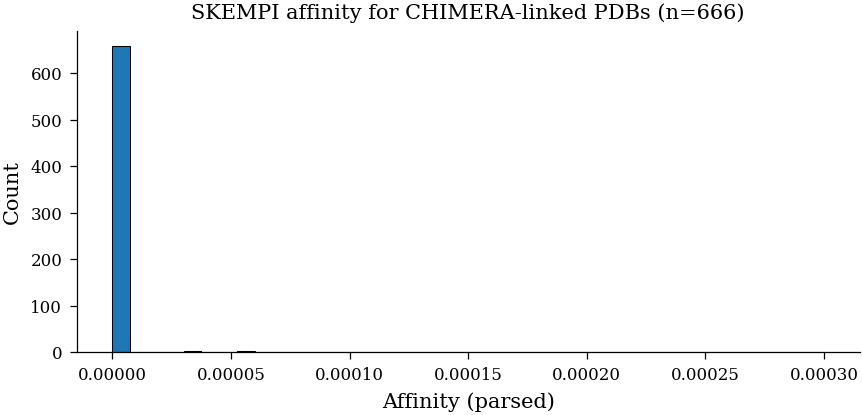

In [20]:
skempi_path = RAW / "skempi_v2.csv"
skempi_df = pd.read_csv(skempi_path, sep=";")
skempi_df["pdb_lower"] = skempi_df["#Pdb"].str[:4].str.lower()

chimera_pdbs = set(df["pdb"].str.lower())
skempi_pdbs = set(skempi_df["pdb_lower"])
overlap = chimera_pdbs & skempi_pdbs

print(f"SKEMPI v2 total entries: {len(skempi_df)}")
print(f"SKEMPI unique PDBs: {len(skempi_pdbs)}")
print(f"CHIMERA unique PDBs: {len(chimera_pdbs)}")
print(f"Overlapping PDBs: {len(overlap)}")
print(f"CHIMERA complexes with SKEMPI data: {df['has_skempi'].sum()}")

# ddG distribution for matched complexes
matched = skempi_df[skempi_df["pdb_lower"].isin(overlap)]
ddg = pd.to_numeric(matched["Affinity_mut_parsed"], errors="coerce").dropna()
if len(ddg) > 0:
    fig, ax = plt.subplots(figsize=(6, 3))
    ax.hist(ddg, bins=40, edgecolor="black", linewidth=0.5)
    ax.set_xlabel("Affinity (parsed)")
    ax.set_ylabel("Count")
    ax.set_title(f"SKEMPI affinity for CHIMERA-linked PDBs (n={len(ddg)})")
    plt.tight_layout()
    plt.show()

## 10. Summary table

In [21]:
summary = {
    "Total complexes": len(df),
    "Unique PDBs": df["pdb"].nunique(),
    "Protein antigens": int((df["antigen_type"] == "protein").sum()),
    "Peptide antigens": int((df["antigen_type"] == "peptide").sum()),
    "SKEMPI-linked": int(df["has_skempi"].sum()),
    "Median resolution (A)": f"{df['resolution'].median():.2f}",
    "Mean VH length (IMGT)": f"{np.mean(vh_lens):.0f}" if vh_lens else "N/A",
    "Mean VL length (IMGT)": f"{np.mean(vl_lens):.0f}" if vl_lens else "N/A",
    "Mean full heavy chain": f"{np.mean(heavy_lens):.0f}",
    "Mean full light chain": f"{np.mean(light_lens):.0f}",
    "Median antigen length": f"{np.median(ag_lens):.0f}",
    "Mean epitope size": f"{np.mean(n_epitope):.1f}",
    "Mean paratope size": f"{np.mean(n_paratope):.1f}",
    "Zero-contact complexes": sum(1 for x in n_contacts if x == 0),
    "Mean graph nodes": f"{np.mean(n_nodes):.0f}",
    "Mean graph edges": f"{np.mean(n_edges):.0f}",
}

summary_df = pd.DataFrame(list(summary.items()), columns=["Metric", "Value"])
print(summary_df.to_string(index=False))

print("\n\nSplit summary:")
for name in split_names:
    s = splits[name]
    tr, va, te = len(s["train"]), len(s["val"]), len(s["test"])
    total = tr + va + te
    print(f"  {name:<20s}  {tr:>5d}/{va:>4d}/{te:>4d}  ({100*tr/total:.0f}/{100*va/total:.0f}/{100*te/total:.0f}%)")

                Metric Value
       Total complexes  2922
           Unique PDBs  2721
      Protein antigens  2485
      Peptide antigens   437
         SKEMPI-linked    29
 Median resolution (A)  2.72
 Mean VH length (IMGT)   121
 Mean VL length (IMGT)   108
 Mean full heavy chain   189
 Mean full light chain   181
 Median antigen length   196
     Mean epitope size  17.9
    Mean paratope size  20.5
Zero-contact complexes     2
      Mean graph nodes   nan
      Mean graph edges   nan


Split summary:
  epitope_group          2338/ 292/ 292  (80/10/10%)
  antigen_fold           2338/ 292/ 292  (80/10/10%)
  temporal               2337/ 292/ 293  (80/10/10%)


/home/exouser/miniconda3/envs/chimera_env/lib/python3.10/site-packages/numpy/core/fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/home/exouser/miniconda3/envs/chimera_env/lib/python3.10/site-packages/numpy/core/_methods.py:129: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


## 11. Unique antibodies and antigens

Unique entity counts:
  Antibodies (VH+VL pairs): 2922
  Unique VH sequences:      2921
  Unique VL sequences:      2906
  Unique antigen sequences: 2470
  Unique antigen names:     1124

Cross-pairing:
  VH paired with >1 VL: 1
  VL paired with >1 VH: 16

Complexes per antigen sequence:
  Max: 30, top 10: [30, 24, 19, 13, 12, 8, 8, 8, 7, 6]
  Singletons (1 complex only): 2212 / 2470 (90%)


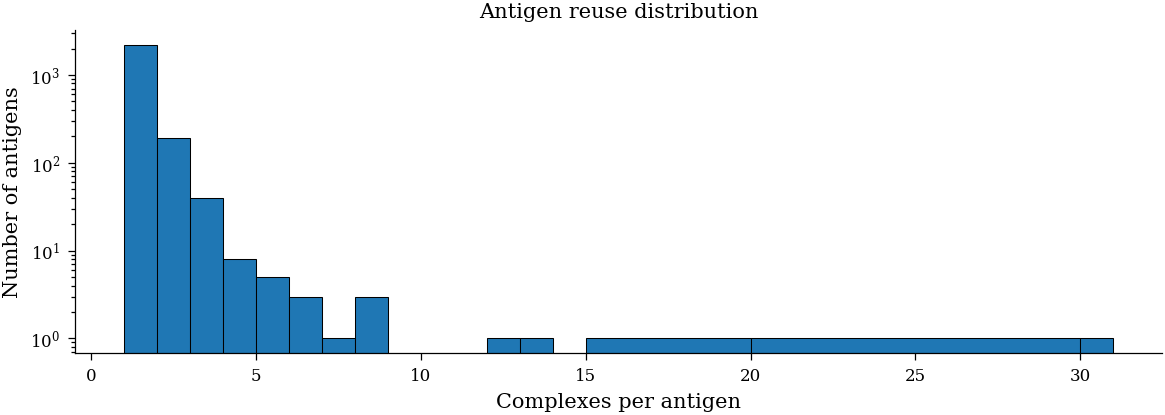

In [22]:
from collections import defaultdict

# Unique antibodies (VH+VL sequence pairs)
ab_pairs = set()
for a in annotations:
    h = a.sequences.get("heavy", "")
    l = a.sequences.get("light", "")
    ab_pairs.add((h, l))

# Unique antigens (by sequence and by name)
ag_seqs = set()
for a in annotations:
    ag_seqs.add(a.sequences.get("antigen", ""))
ag_names = set(df["antigen_name"].dropna().unique())

# VH/VL cross-pairing
vh_to_vl = defaultdict(set)
vl_to_vh = defaultdict(set)
for a in annotations:
    h = a.sequences.get("heavy", "")
    l = a.sequences.get("light", "")
    if h and l:
        vh_to_vl[h].add(l)
        vl_to_vh[l].add(h)
multi_vl = sum(1 for v in vh_to_vl.values() if len(v) > 1)
multi_vh = sum(1 for v in vl_to_vh.values() if len(v) > 1)

print("Unique entity counts:")
print(f"  Antibodies (VH+VL pairs): {len(ab_pairs)}")
print(f"  Unique VH sequences:      {len(vh_to_vl)}")
print(f"  Unique VL sequences:      {len(vl_to_vh)}")
print(f"  Unique antigen sequences: {len(ag_seqs)}")
print(f"  Unique antigen names:     {len(ag_names)}")
print(f"\nCross-pairing:")
print(f"  VH paired with >1 VL: {multi_vl}")
print(f"  VL paired with >1 VH: {multi_vh}")

# Complexes per unique antigen sequence
ag_complex_counts = Counter()
for a in annotations:
    ag_complex_counts[a.sequences.get("antigen", "")] += 1
vals = sorted(ag_complex_counts.values(), reverse=True)
singletons = sum(1 for v in vals if v == 1)

print(f"\nComplexes per antigen sequence:")
print(f"  Max: {vals[0]}, top 10: {vals[:10]}")
print(f"  Singletons (1 complex only): {singletons} / {len(ag_seqs)} ({100*singletons/len(ag_seqs):.0f}%)")

fig, ax = plt.subplots(figsize=(8, 3))
bins = list(range(1, 16)) + [20, 30, max(vals) + 1]
ax.hist(vals, bins=bins, edgecolor="black", linewidth=0.5)
ax.set_xlabel("Complexes per antigen")
ax.set_ylabel("Number of antigens")
ax.set_title("Antigen reuse distribution")
ax.set_yscale("log")
plt.tight_layout()
plt.show()

## 12. Multi-epitope antigens

Multi-epitope antigens: 258 / 2470 unique antigen sequences
Single-epitope antigens: 2212

Epitopes per multi-epitope antigen:
  Max: 30, top 15: [30, 24, 13, 12, 10, 8, 8, 8, 7, 6, 6, 6, 5, 5, 5]
  Mean: 2.7

Complexes targeting multi-epitope antigens: 710 / 2922


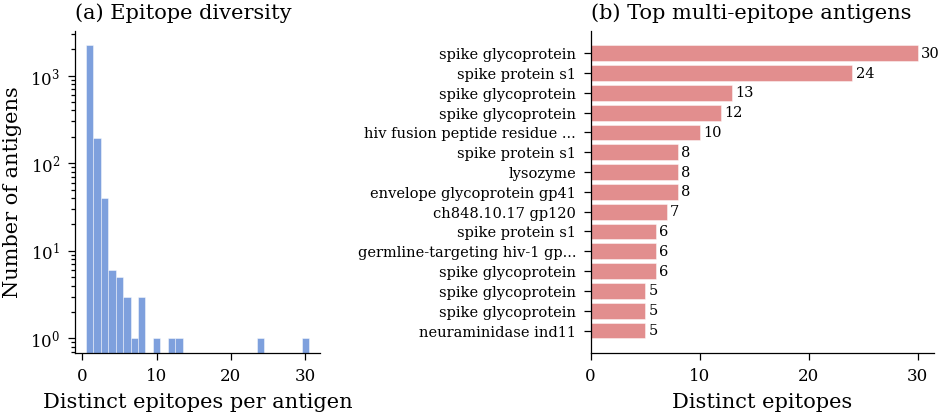

In [23]:
# Multi-epitope antigens: same antigen sequence targeted at different epitopes
ag_to_epitopes = defaultdict(set)
ag_to_ids = defaultdict(list)
for a in annotations:
    ag = a.sequences.get("antigen", "")
    epi = tuple(sorted((c, r) for c, r, _ in a.epitope_residues))
    ag_to_epitopes[ag].add(epi)
    ag_to_ids[ag].append(a.complex_id)

multi_epi = {ag: eps for ag, eps in ag_to_epitopes.items() if len(eps) > 1 and ag}
n_epitopes_per_ag = sorted([len(v) for v in multi_epi.values()], reverse=True)

print(f"Multi-epitope antigens: {len(multi_epi)} / {len(ag_seqs)} unique antigen sequences")
print(f"Single-epitope antigens: {len(ag_seqs) - len(multi_epi)}")
print(f"\nEpitopes per multi-epitope antigen:")
print(f"  Max: {n_epitopes_per_ag[0]}, top 15: {n_epitopes_per_ag[:15]}")
print(f"  Mean: {np.mean(n_epitopes_per_ag):.1f}")

# Total complexes involved in multi-epitope antigens
multi_epi_complexes = sum(len(ag_to_ids[ag]) for ag in multi_epi)
print(f"\nComplexes targeting multi-epitope antigens: {multi_epi_complexes} / {len(annotations)}")

# Distribution
all_epi_counts = [len(ag_to_epitopes[ag]) for ag in ag_to_epitopes if ag]

fig, axes = plt.subplots(1, 2, figsize=(6.5, 3.0),
                         gridspec_kw={'width_ratios': [1, 1.4]})

# (a) Epitope diversity histogram
axes[0].hist(all_epi_counts, bins=range(1, max(all_epi_counts) + 2),
             edgecolor='white', linewidth=0.3, align='left',
             color=_blue, alpha=0.7)
axes[0].set_xlabel('Distinct epitopes per antigen')
axes[0].set_ylabel('Number of antigens')
axes[0].set_title('(a) Epitope diversity', loc='left')
axes[0].set_yscale('log')

# Top multi-epitope antigens by name
ag_seq_to_name = {}
for _, row in df.iterrows():
    cid = f"{row['pdb']}_{row['Hchain']}_{row['Lchain']}_{row['antigen_chain']}"
    for a in annotations:
        if a.complex_id == cid:
            ag_seq_to_name[a.sequences.get("antigen", "")] = row.get("antigen_name", "unknown")
            break

# (b) Top 15 multi-epitope antigens
top_multi = sorted(multi_epi.keys(), key=lambda ag: len(multi_epi[ag]), reverse=True)[:15]
names = []
counts = []
for ag in top_multi:
    name = ag_seq_to_name.get(ag, f"seq_{len(ag)}aa")
    if len(name) > 30:
        name = name[:27] + "..."
    names.append(name)
    counts.append(len(multi_epi[ag]))

axes[1].barh(range(len(names)), counts[::-1], color=_red, alpha=0.7,
             edgecolor='white', linewidth=0.3)
axes[1].set_yticks(range(len(names)))
axes[1].set_yticklabels(names[::-1], fontsize=7)
axes[1].set_xlabel('Distinct epitopes')
axes[1].set_title('(b) Top multi-epitope antigens', loc='left')
for i, v in enumerate(counts[::-1]):
    axes[1].text(v + 0.3, i, str(v), va='center', fontsize=7)

plt.tight_layout(w_pad=2.0)
plt.savefig('figures/multi_epitope_antigens.pdf', bbox_inches='tight')
plt.savefig('figures/multi_epitope_antigens.png', dpi=300, bbox_inches='tight')
plt.show()

## 13. Antigen species and disease targets

Antigen origin breakdown:
  Human                  797 (27.3%)
  Viral                 1531 (52.4%)
  Bacterial               82 (2.8%)
  Parasitic              150 (5.1%)
  Other/unknown          362 (12.4%)


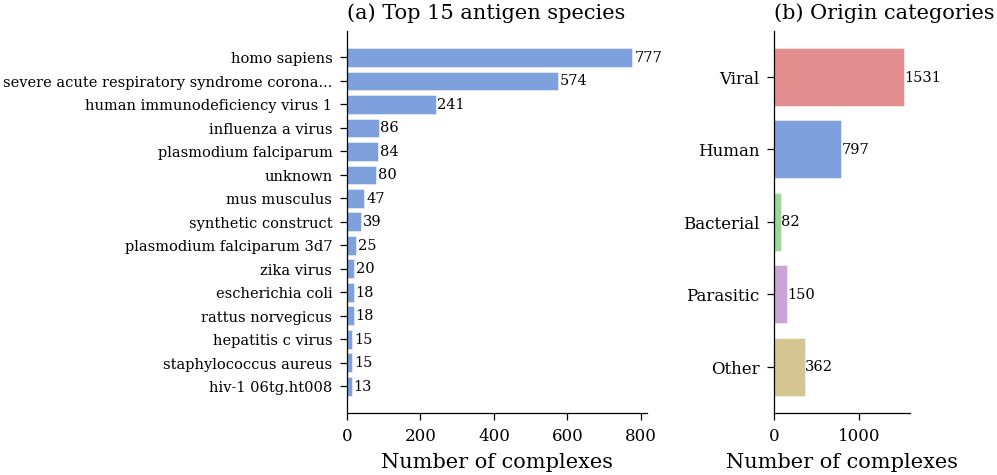

In [24]:
# Antigen species breakdown
ag_species = df['antigen_species'].fillna('unknown').str.lower().str.strip()
species_counts = ag_species.value_counts()

# Group into biological categories
viral = species_counts[species_counts.index.str.contains(
    'virus|sars|covid|influenza|hiv|zika|ebola|hepatitis|dengue', na=False)]
human = species_counts[species_counts.index.str.contains('homo sapiens', na=False)]
bacterial = species_counts[species_counts.index.str.contains(
    'streptococcus|staphylococcus|escherichia|pseudomonas|clostridium|bacillus|mycobacterium', na=False)]
parasitic = species_counts[species_counts.index.str.contains(
    'plasmodium|toxoplasma|trypanosoma|leishmania', na=False)]
other_n = len(df) - human.sum() - viral.sum() - parasitic.sum() - bacterial.sum()

print('Antigen origin breakdown:')
for label, val in [('Human', human.sum()), ('Viral', viral.sum()),
                   ('Bacterial', bacterial.sum()), ('Parasitic', parasitic.sum()),
                   ('Other/unknown', other_n)]:
    print(f'  {label:<20s} {val:>5d} ({100*val/len(df):.1f}%)')

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(6.5, 3.4),
                                gridspec_kw={'width_ratios': [2.2, 1]})

# (a) Top 15 species
top_sp = species_counts.head(15)
y_pos = range(len(top_sp))
ax1.barh(y_pos, top_sp.values, color=_blue, alpha=0.7,
         edgecolor='white', linewidth=0.3)
ax1.set_yticks(list(y_pos))
names = [s.replace('_', ' ') for s in top_sp.index]
names = [n[:40] + '...' if len(n) > 43 else n for n in names]
ax1.set_yticklabels(names, fontsize=7)
ax1.invert_yaxis()
ax1.set_xlabel('Number of complexes')
ax1.set_title('(a) Top 15 antigen species', loc='left')
for i, v in enumerate(top_sp.values):
    ax1.text(v + 5, i, str(v), va='center', fontsize=7)

# (b) Origin categories (bar chart instead of pie)
cats = ['Viral', 'Human', 'Bacterial', 'Parasitic', 'Other']
vals = [viral.sum(), human.sum(), bacterial.sum(), parasitic.sum(), other_n]
colors = [_red, _blue, _green, _purple, _gold]
ax2.barh(range(len(cats)), vals, color=colors, alpha=0.7,
         edgecolor='white', linewidth=0.3)
ax2.set_yticks(range(len(cats)))
ax2.set_yticklabels(cats)
ax2.invert_yaxis()
ax2.set_xlabel('Number of complexes')
ax2.set_title('(b) Origin categories', loc='left')
for i, v in enumerate(vals):
    ax2.text(v + 5, i, str(v), va='center', fontsize=7)

plt.tight_layout(w_pad=1.5)
plt.savefig('figures/antigen_species.pdf', bbox_inches='tight')
plt.savefig('figures/antigen_species.png', dpi=300, bbox_inches='tight')
plt.show()

## 15. Baseline results: radar plots

In [25]:
# ── Load baseline results from CSV ─────────────────────────────────
import re

CSV_PATH = Path.home() / 'chimera' / 'baselines' / 'all_baselines_results.csv'
res_df = pd.read_csv(CSV_PATH, sep='\t')

def parse_mean(val):
    """Extract mean from 'mean+-std' string."""
    if pd.isna(val) or val == '--':
        return np.nan
    m = re.match(r'([\d.]+)\s*[±+-]+\s*([\d.]+)', str(val))
    return float(m.group(1)) if m else np.nan

# Parse all metric columns
METRICS = ['aar', 'caar', 'ppl', 'rmsd', 'tm_score', 'fnat', 'irmsd', 'dockq', 'epitope_f1', 'n_liabilities']
for col in METRICS:
    res_df[col + '_mean'] = res_df[col].apply(parse_mean)

# Canonical display names
METHOD_NAMES = {
    'raad': 'RAAD', 'mean': 'MEAN', 'dymean': 'dyMEAN', 'diffab': 'DiffAb',
    'abflownet': 'AbFlowNet', 'abmedg': 'AbMEGD', 'radab': 'RADAb',
    'dyab': 'dyAb', 'refinegnn': 'RefineGNN', 'abdockgen': 'AbDockGen', 'abode': 'AbODE',
}
res_df['method'] = res_df['baseline'].map(METHOD_NAMES)

print(f'Loaded {len(res_df)} rows from {CSV_PATH.name}')
print(f'Baselines: {sorted(res_df["method"].unique())}')
print(f'Splits:    {sorted(res_df["split"].unique())}')
print(f'CDR types: {sorted(res_df["cdr_type"].unique())}')

Loaded 138 rows from all_baselines_results.csv
Baselines: ['AbDockGen', 'AbFlowNet', 'AbMEGD', 'AbODE', 'DiffAb', 'MEAN', 'RAAD', 'RADAb', 'RefineGNN', 'dyAb', 'dyMEAN']
Splits:    ['antigen_fold', 'epitope_group', 'temporal']
CDR types: ['H1', 'H2', 'H3', 'L1', 'L2', 'L3']


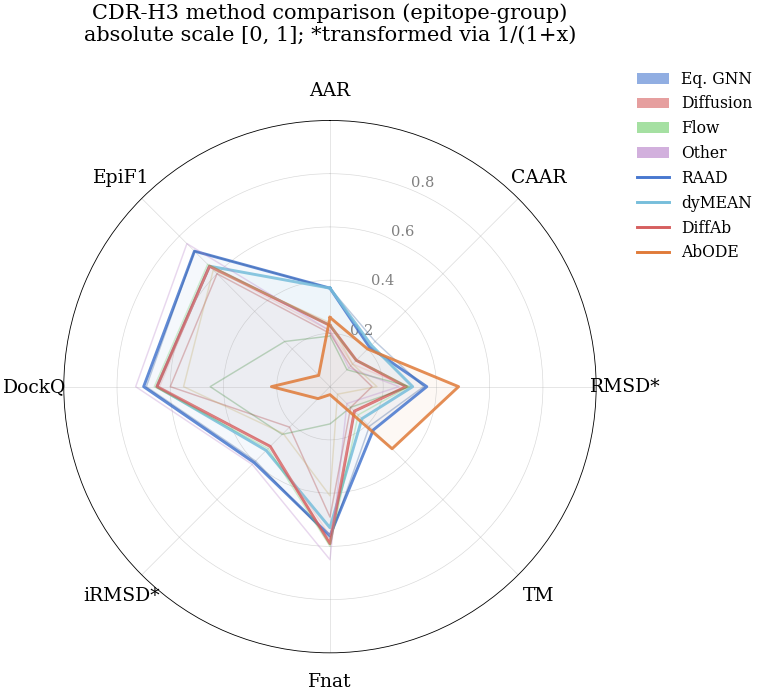


Highlighted methods (bold lines): RAAD, dyMEAN, DiffAb, AbODE
Others shown as faint lines for context
RMSD* and iRMSD* show 1/(1+x) so that higher = better


In [26]:
# ── Shared radar utilities ────────────────────────────────────────
from matplotlib.patches import Patch

# 6 metrics already in [0,1]; RMSD and iRMSD transformed via 1/(1+x)
RAW_METRICS = ['aar', 'caar', 'rmsd', 'tm_score', 'fnat', 'irmsd', 'dockq', 'epitope_f1']
RADAR_LABELS = ['AAR', 'CAAR', 'RMSD*', 'TM', 'Fnat', 'iRMSD*', 'DockQ', 'EpiF1']

METHOD_ORDER = [
    'RAAD', 'MEAN', 'dyMEAN',           # Equivariant GNN
    'DiffAb', 'AbMEGD', 'RADAb',        # Diffusion
    'AbFlowNet', 'dyAb',                # Flow matching
    'RefineGNN', 'AbDockGen', 'AbODE',  # Other
]

METHOD_COLORS = {
    'RAAD':      '#4878CF',  'MEAN':      '#2A5495',  'dyMEAN':    '#77BEDB',
    'DiffAb':    '#D65F5F',  'AbMEGD':    '#E8A0A0',  'RADAb':     '#A83232',
    'AbFlowNet': '#6ACC65',  'dyAb':      '#3B8837',
    'RefineGNN': '#B47CC7',  'AbDockGen': '#C4AD66',  'AbODE':     '#E07B39',
}

_paradigm_colors = {
    'Eq. GNN': '#4878CF', 'Diffusion': '#D65F5F',
    'Flow':    '#6ACC65', 'Other':     '#B47CC7',
}

HIGHLIGHT = {'RAAD', 'dyMEAN', 'DiffAb', 'AbODE'}

def get_absolute_values(df, cdr, methods):
    """Extract metric values, transform to [0,1] higher=better.
    6 metrics kept as-is; RMSD/iRMSD via 1/(1+x)."""
    sub = df[(df['split'] == 'epitope_group') & (df['cdr_type'] == cdr)]
    sub = sub.set_index('method')
    vals = np.full((len(methods), len(RAW_METRICS)), np.nan)
    for i, m in enumerate(methods):
        if m not in sub.index:
            continue
        for j, met in enumerate(RAW_METRICS):
            v = sub.loc[m, met + '_mean']
            if met in ('rmsd', 'irmsd'):
                vals[i, j] = 1.0 / (1.0 + v) if not np.isnan(v) else np.nan
            else:
                vals[i, j] = v
    return vals

# ── (a) Radar: CDR-H3 method comparison (absolute scale) ─────────
h3_vals = get_absolute_values(res_df, 'H3', METHOD_ORDER)

n_met = len(RAW_METRICS)
angles = np.linspace(0, 2 * np.pi, n_met, endpoint=False).tolist()
angles += angles[:1]

fig, ax = plt.subplots(figsize=(5.5, 5.5), subplot_kw=dict(polar=True))
ax.set_theta_offset(np.pi / 2)
ax.set_theta_direction(-1)

for i, m in enumerate(METHOD_ORDER):
    v = h3_vals[i].tolist() + [h3_vals[i, 0]]
    color = METHOD_COLORS[m]
    if m in HIGHLIGHT:
        ax.plot(angles, v, linewidth=1.4, alpha=0.85, color=color, label=m)
        ax.fill(angles, v, alpha=0.05, color=color)
    else:
        ax.plot(angles, v, linewidth=0.7, alpha=0.3, color=color, label=m)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(RADAR_LABELS, fontsize=9)
ax.set_ylim(0, 1.0)
ax.set_yticks([0.2, 0.4, 0.6, 0.8])
ax.set_yticklabels(['0.2', '0.4', '0.6', '0.8'], fontsize=7, color='grey')
ax.spines['polar'].set_linewidth(0.4)
ax.grid(linewidth=0.3, alpha=0.5)

paradigm_handles = [Patch(facecolor=c, alpha=0.6, label=p) for p, c in _paradigm_colors.items()]
method_handles = [plt.Line2D([0], [0], color=METHOD_COLORS[m], lw=1.4, label=m)
                  for m in METHOD_ORDER if m in HIGHLIGHT]
ax.legend(handles=paradigm_handles + method_handles,
          loc='upper right', bbox_to_anchor=(1.32, 1.12),
          frameon=False, fontsize=7.5, ncol=1)

ax.set_title('CDR-H3 method comparison (epitope-group)\n'
             'absolute scale [0, 1]; *transformed via 1/(1+x)',
             fontsize=10, pad=20)

plt.tight_layout()
plt.savefig('figures/radar_methods_metrics.pdf', bbox_inches='tight')
plt.savefig('figures/radar_methods_metrics.png', dpi=300, bbox_inches='tight')
plt.show()

print('\nHighlighted methods (bold lines): RAAD, dyMEAN, DiffAb, AbODE')
print('Others shown as faint lines for context')
print('RMSD* and iRMSD* show 1/(1+x) so that higher = better')

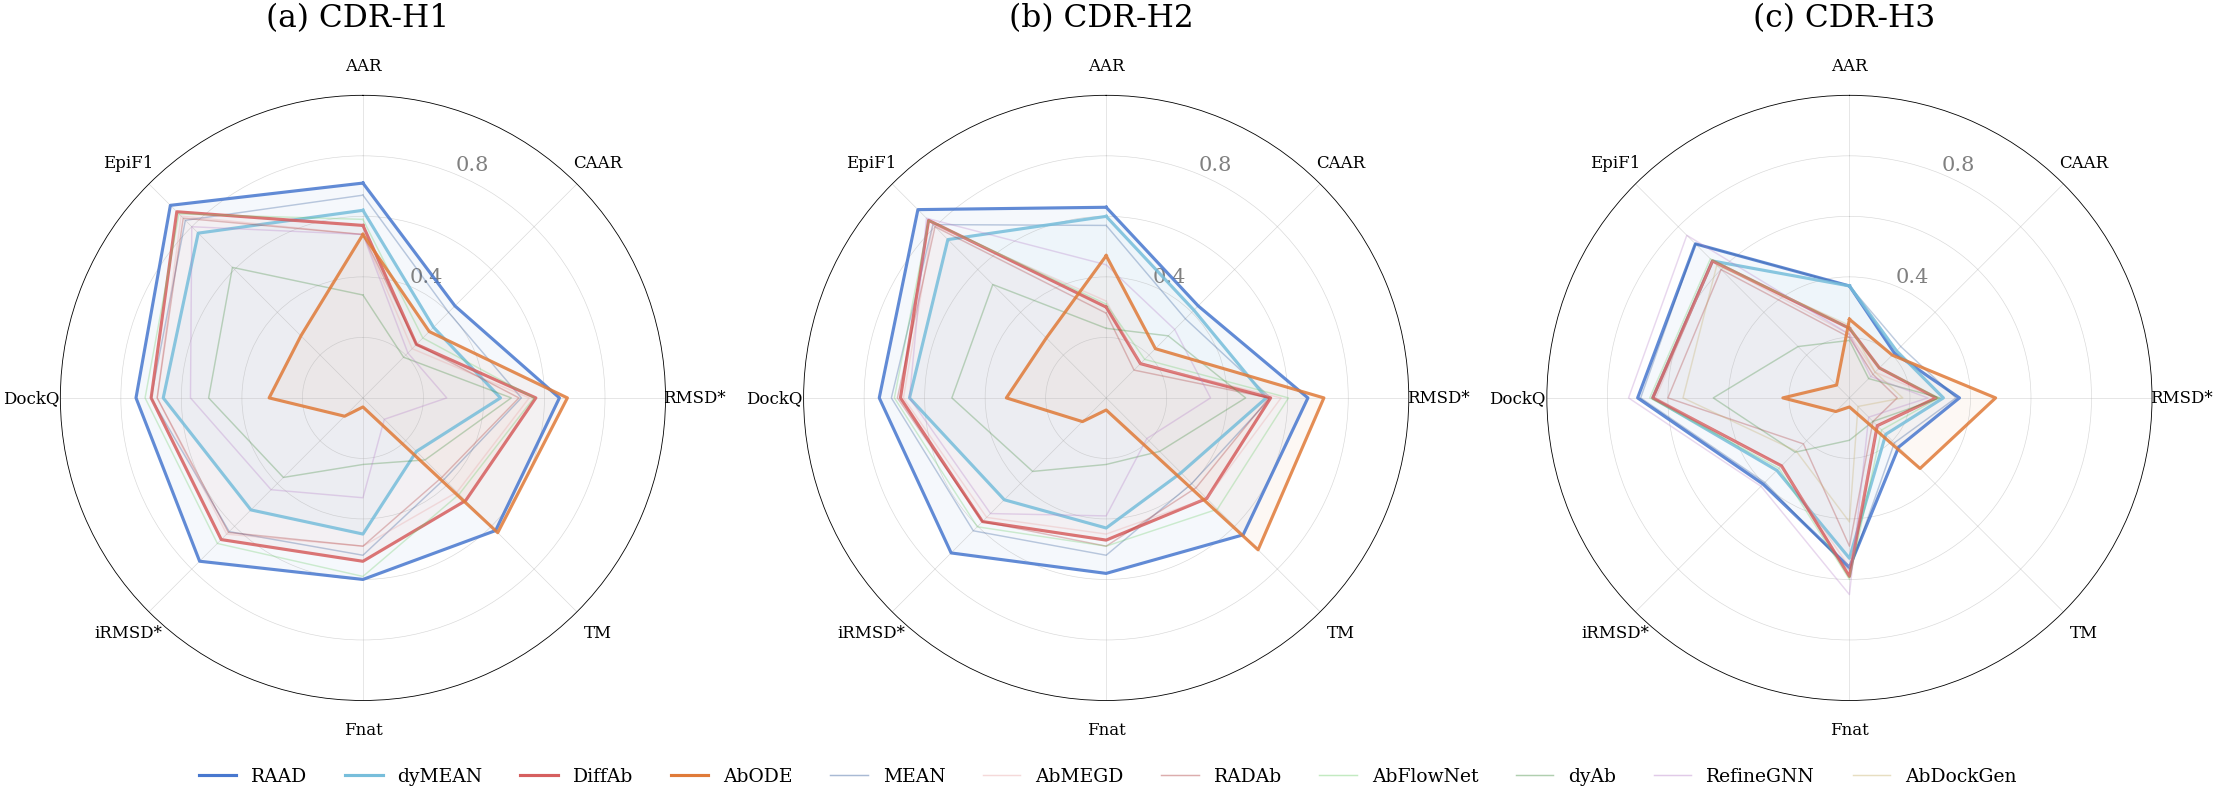

RMSD*/iRMSD* = 1/(1+x)


In [27]:
# ── (b) Three-panel radar: H1 / H2 / H3 (absolute scale) ─────────
CDR_PANELS = ['H1', 'H2', 'H3']

all_vals = {}
methods_per_cdr = {}
for cdr in CDR_PANELS:
    methods = METHOD_ORDER if cdr == 'H3' else [m for m in METHOD_ORDER if m != 'AbDockGen']
    all_vals[cdr] = get_absolute_values(res_df, cdr, methods)
    methods_per_cdr[cdr] = methods

n_met = len(RAW_METRICS)
angles = np.linspace(0, 2 * np.pi, n_met, endpoint=False).tolist()
angles += angles[:1]

fig, axes = plt.subplots(1, 3, figsize=(15, 5.2), subplot_kw=dict(polar=True))

for ax_idx, (ax, cdr) in enumerate(zip(axes, CDR_PANELS)):
    methods = methods_per_cdr[cdr]
    vals = all_vals[cdr]

    ax.set_theta_offset(np.pi / 2)
    ax.set_theta_direction(-1)

    for i, m in enumerate(methods):
        v = vals[i].tolist() + [vals[i, 0]]
        color = METHOD_COLORS[m]
        if m in HIGHLIGHT:
            ax.plot(angles, v, linewidth=1.5, alpha=0.85, color=color, label=m)
            ax.fill(angles, v, alpha=0.05, color=color)
        else:
            ax.plot(angles, v, linewidth=0.7, alpha=0.3, color=color)

    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(RADAR_LABELS, fontsize=8)
    ax.set_ylim(0, 1.0)
    ax.set_yticks([0.2, 0.4, 0.6, 0.8])
    ax.set_yticklabels(['', '0.4', '', '0.8'], fontsize=10, color='grey')
    ax.spines['polar'].set_linewidth(0.4)
    ax.grid(linewidth=0.3, alpha=0.5)

    panel_label = chr(ord('a') + ax_idx)
    n_m = len(methods)
    ax.set_title(f'({panel_label}) CDR-{cdr} ', fontsize=15, pad=15)

highlight_handles = [plt.Line2D([0], [0], color=METHOD_COLORS[m], lw=1.5, label=m)
                     for m in METHOD_ORDER if m in HIGHLIGHT]
faint_handles = [plt.Line2D([0], [0], color=METHOD_COLORS[m], lw=0.7, alpha=0.4, label=m)
                 for m in METHOD_ORDER if m not in HIGHLIGHT]
fig.legend(handles=highlight_handles + faint_handles, loc='lower center',
           ncol=len(METHOD_ORDER), frameon=False, fontsize=9,
           bbox_to_anchor=(0.5, -0.04))

# fig.suptitle('Heavy-chain CDR generation comparison',
#              fontsize=13, y=1.02)

plt.tight_layout(rect=[0, 0.04, 1, 0.98])
plt.savefig('figures/radar_h1_h2_h3.pdf', bbox_inches='tight')
plt.savefig('figures/radar_h1_h2_h3.png', dpi=300, bbox_inches='tight')
plt.show()

print('RMSD*/iRMSD* = 1/(1+x)')
# print('AbDockGen only has H3 (10 methods for H1/H2, 11 for H3)')